In [95]:
import os
import math
import pickle
import sys

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from matplotlib.lines import Line2D
from scipy import stats
from scipy.stats import spearmanr

from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, FONT_SIZES

plt.rcParams['figure.dpi'] = 300
plt.rcParams.update(FONT_SIZES)

In [96]:
#Define the test set to be processed (e.g. without_errors_300bp, without_errors_75bp, with_errors_300bp etc.)
data_types = ["without_errors_300bp"] #replace _300bp with any other test set sequence length (e.g. _75bp, _700bp etc.)

#Overlap required to be considered a TP
overlap_criteria = 1

#Toggle: set True to load pre-computed results from disk (fast), False to run full data processing
LOAD_PROCESSED_DATA = True

In [97]:
project_root = "../../../.."

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

# Load genome info from CSV and create dict for all test accessions
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

# Families that use translation table 4 (Mycoplasmataceae and related)
TT4_FAMILIES = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        # Assign translation table based on family
        translation_table = 4 if row['family'] in TT4_FAMILIES else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

# Create filtered accession lists by translation table
tt4_accessions = [acc for acc in all_test_accessions if acc in all_genomes and all_genomes[acc]['translation_table'] == 4]
tt11_accessions = [acc for acc in all_test_accessions if acc in all_genomes and all_genomes[acc]['translation_table'] == 11]

print(f"Translation Table 4 genomes: {len(tt4_accessions)}")
print(f"Translation Table 11 genomes: {len(tt11_accessions)}")

#"Reference" test accessions (1 per family)
genomes = {
    'GCF_000011125.1': {'translation_table': 11, 'gc_content': 56.3, 'domain': 'Archaea'},
    'GCF_000008665.1': {'translation_table': 11, 'gc_content': 48.6, 'domain': 'Archaea'},
    'GCF_004799605.1': {'translation_table': 11, 'gc_content': 66.3, 'domain': 'Archaea'},
    'GCF_000017165.1': {'translation_table': 11, 'gc_content': 31.3, 'domain': 'Archaea'},
    'GCF_000007345.1': {'translation_table': 11, 'gc_content': 42.7, 'domain': 'Archaea'},
    'GCF_000012545.1': {'translation_table': 11, 'gc_content': 27.6, 'domain': 'Archaea'},
    'GCF_000007365.1': {'translation_table': 11, 'gc_content': 25.3, 'domain': 'Bacteria'},
    'GCF_000009045.1': {'translation_table': 11, 'gc_content': 43.5, 'domain': 'Bacteria'},
    'GCF_025998455.1': {'translation_table': 11, 'gc_content': 38.5, 'domain': 'Bacteria'},
    'GCF_000195955.2': {'translation_table': 11, 'gc_content': 65.6, 'domain': 'Bacteria'},
    'GCF_020736045.1': {'translation_table': 11, 'gc_content': 38.2, 'domain': 'Bacteria'},
    'GCF_000012765.1': {'translation_table': 4, 'gc_content': 23.8, 'domain': 'Bacteria'},
    'GCF_028609885.1': {'translation_table': 11, 'gc_content': 61.4, 'domain': 'Bacteria'},
    'GCF_000005845.2': {'translation_table': 11, 'gc_content': 50.8, 'domain': 'Bacteria'},
    'GCF_000006765.1': {'translation_table': 11, 'gc_content': 66.6, 'domain': 'Bacteria'},
    'GCF_000013425.1': {'translation_table': 11, 'gc_content': 32.9, 'domain': 'Bacteria'}}

test_accessions = list(genomes.keys()) #List of the "reference" test accessions 

_script_name = "organisms_families_gc_content"

# Cache path encodes overlap_criteria — each value gets its own subdirectory, so
# LOAD_PROCESSED_DATA will always point to data generated with the same setting.
_cache_dir = (
    f"{project_root}/data/processed_data/report_results/without_errors/{_script_name}"
    f"/oc_{overlap_criteria}"
)

Translation Table 4 genomes: 3
Translation Table 11 genomes: 212


In [98]:
def load_in_processed_datasets(test_accession, data_type, project_root=project_root):
    #Load in testset data
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as testset_dict_file:
        testset_dict = pickle.load(testset_dict_file)

    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as read_names_list_file:
        read_names_list = pickle.load(read_names_list_file)

    #Load on prodigal preds
    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/model_preds_dict.pkl", "rb") as preds_prodigal_dict_file:
        preds_prodigal = pickle.load(preds_prodigal_dict_file)

    #Load in FGS predictions
    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}/{test_accession}.pkl", "rb") as preds_fgs_dict_file:
        preds_fgs_complete = pickle.load(preds_fgs_dict_file)

    with open(f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl", "rb") as model_preds_dict_file:
        preds_deep_cds = pickle.load(model_preds_dict_file)

    return read_names_list, testset_dict, preds_prodigal, \
        preds_fgs_complete, preds_deep_cds

In [99]:
def calculate_iou(coord1, coord2):
    """
    Calculate Intersection over Union (IoU) for two gene coordinates.
    Each coord (coord1 and coord2, respectively) is a tuple: (cds_start, cds_stop, reading_frame)
    Only compares genes in the same reading frame.
    
    Returns:
      iou: IoU value between 0 and 1, or 0 if different reading frames.
    """

    start1, stop1, rf1 = coord1
    start2, stop2, rf2 = coord2
    
    #Only compare genes in the same reading frame
    if rf1 != rf2:
        return 0.0
    
    #Calculate intersection
    intersection_start = max(start1, start2)
    intersection_stop = min(stop1, stop2)
    
    #No intersection if start > stop
    if intersection_start >= intersection_stop:
        return 0.0
    
    intersection_length = intersection_stop - intersection_start
    
    #Calculate union
    union_start = min(start1, start2)
    union_stop = max(stop1, stop2)
    union_length = union_stop - union_start
    
    #Calculate IoU
    iou = intersection_length / union_length if union_length > 0 else 0.0
    
    return iou

In [100]:
def find_matching_genes(predicted_coords, actual_coords, overlap_criteria):
    """
    Find matching genes based on IoU overlap criteria.

    Args:
        predicted_coords (list): List of predicted gene coordinates (tuples).
        actual_coords (list): List of actual gene coordinates (tuples).
        overlap_criteria (float): Minimum IoU required to consider a match.
    
    Returns:
        matched_pairs: list of (pred_idx, actual_idx) pairs that match
        len(matched_paires) = tp_count: number of true positives
    """

    #Initialize
    matched_pairs = []
    used_actual = set()  #Track which actual genes have been matched
    used_predicted = set()  #Track which predicted genes have been matched
    
    #For each predicted gene, find the best matching actual gene
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        
        for actual_idx, actual_coord in enumerate(actual_coords):
            #Skip if this actual gene is already matched
            if actual_idx in used_actual:
                continue
                
            iou = calculate_iou(pred_coord, actual_coord)
            
            #Check if this is better than current best and meets criteria
            if iou >= overlap_criteria and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        
        #If we found a valid match
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
            used_predicted.add(pred_idx)

    
    return matched_pairs, len(matched_pairs)


In [101]:
def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names, overlap_criteria):
    """
    Calculate sensitivity, precision, and F1-score for given overlap criteria.
    Overlap is based on IoU (Intersection over Union).
    
    Precision (PPV): The ratio of true positives to all predicted genes; TP / (TP + FP)
    Sensitivity (Recall): The ratio of true positives to all actual genes; TP / (TP + FN)
    F1-score: Harmonic mean of precision and sensitivity; 2 * (precision * sensitivity) / (precision + sensitivity)
    
    Args:
        testset_dict: Dictionary containing ground truth CDS coordinates
        model_preds_dict: Dictionary containing predicted CDS coordinates
        all_test_read_names: List of all read names to evaluate
        overlap_criteria: Minimum IoU threshold for considering a match (0.0< to 1.0)
    
    Returns:
        results: Dictionary containing calculated metrics
    """
    
    #Initialize
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0
    
    #Iterate through each read
    for read_name in all_test_read_names:

        #Get coordinates for this read; both for test set and model predictions
        cds_coords_testset = []
        cds_coords_model = []
        
        if read_name in testset_dict:
            cds_coords_testset = testset_dict[read_name].get("cds_coords", [])
        
        if read_name in model_preds_dict:
            cds_coords_model = model_preds_dict[read_name].get("cds_coords", [])
        
        #Count genes for this read
        num_predicted = len(cds_coords_model) #predicted gene fragments
        num_actual = len(cds_coords_testset)  #actual gene fragments

        #Find matching genes based on overlap criteria
        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset, overlap_criteria)

        #Update counts
        total_predicted_genes += num_predicted
        total_actual_genes += num_actual
        total_tp += tp_count
    
    #Calculate overall metrics
    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes - total_tp
    
    #Calculate precision
    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    
    #Calculate recall/sensitivity
    recall = total_tp / total_actual_genes if total_actual_genes > 0 else 0.0
    
    #Calculate F1-score (harmonic mean of precision and recall)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    #Store results
    results = {
        'overlap_criteria': overlap_criteria,
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }
    
    return results

In [102]:
def get_metric_for_models(performance_metric, performance_metrics_genomes_dict):
    """
    Get performance metric for all models across genomes in a easy-to-plot dictionary format.
    
    Args:
        performance_metric (str): The performance metric to extract (e.g., 'precision', 'recall', 'f1_score').
        performance_metrics_genomes_dict (dict): A dictionary containing performance metrics for each genome and model.
    
    Returns:
        dict: A dictionary with genome accessions and model scores
    """
    if not performance_metrics_genomes_dict:
        return {}
    
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_genomes_dict.values()))
    model_names = [key for key in first_genome.keys()]
    
    # Initialize result dictionary
    result_dict = {"genome_accession": []}
    for model_name in model_names:
        result_dict[model_name] = []
    
    # Extract metric for each genome and model
    for genome_accession, models_data in performance_metrics_genomes_dict.items():
        result_dict["genome_accession"].append(genome_accession)
        
        for model_name in model_names:
            if model_name in models_data and performance_metric in models_data[model_name]:
                result_dict[model_name].append(models_data[model_name][performance_metric])
            else:
                result_dict[model_name].append(None)  # Handle missing data
    
    return result_dict

In [103]:
def plot_metric_per_genome_bars(metric_data, metric_name, data_type, model_display_names=None,
                                 colors=None, genome_metadata=None):
    """
    Plot specified performance metric across different genomes and models using bar charts.

    Args:
        metric_data (dict): Dictionary containing genome accessions and model scores
        metric_name (str): Name of the performance metric to display on the y-axis
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for the bars. If None, default colors will be used
        genome_metadata (dict, optional): Dictionary with genome metadata (translation_table, gc_content, domain)
    """
    genome_accessions = metric_data["genome_accession"]
    model_names = [key for key in metric_data.keys() if key != "genome_accession"]

    if not model_names:
        print("No model data found!")
        return

    # Build x-axis labels: abbreviated italic species name + metadata
    x_labels = []
    for acc in genome_accessions:
        if acc in genome_info_df.index:
            species = genome_info_df.loc[acc, 'species']
            name = species if pd.notna(species) and species != '' else acc
        else:
            name = acc

        parts = name.split(' ', 1)
        abbreviated = f"{parts[0][0]}. {parts[1]}" if len(parts) == 2 else name
        italic_name = r'\textit{' + abbreviated + r'}'

        if genome_metadata is not None and acc in genome_metadata:
            meta = genome_metadata[acc]
            tt = meta.get('translation_table', 'N/A')
            gc = meta.get('gc_content', 'N/A')
            domain = meta.get('domain', 'N/A')[0]
            label = f"{italic_name}\n(TT:{tt}, GC:{gc}\\%, {domain})"
        else:
            label = italic_name
        x_labels.append(label)

    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names

    if colors is None:
        default_colors = ['skyblue', 'lightgreen', 'orchid', 'coral', 'gold', 'lightgray', 'pink', 'lightcyan']
        colors = default_colors[:len(model_names)]

    x = np.arange(len(genome_accessions))
    n_models = len(model_names)
    width = 0.9 / n_models

    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(max(18, len(genome_accessions) * 1.2), 8))

    for i, model_name in enumerate(model_names):
        scores = metric_data[model_name]
        valid_scores = [score if score is not None else 0 for score in scores]
        x_pos = x - (n_models - 1) * width / 2 + i * width
        ax.bar(x_pos, valid_scores, width,
               label=display_names.get(model_name, model_name),
               alpha=0.8, color=colors[i % len(colors)])

    ax.set_ylabel(metric_name.replace("_", " ").title(), fontsize=16)
    ax.set_title(
        f'{metric_name.replace("_", " ").title()} Across Models and Genomes in Test Set (Overall CDS-level)\n'
        f'{data_type.capitalize().replace("_", " ")}',
        fontsize=18, fontweight='normal'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(bbox_to_anchor=(0.5, -0.38), loc='upper center', ncol=len(model_names), fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, len(genome_accessions) - 0.5)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


In [104]:
def plot_all_models_comparison(performance_metric, performance_metrics_genomes_dict, data_type, genome_metadata=None):
    """
    Plot all models for a given metric across reference organisms (one per family),
    then print a LaTeX table with species as rows, models as columns, best value per
    row in bold, and an aggregated row at the bottom.

    Args:
        performance_metric (str): The performance metric to plot
        performance_metrics_genomes_dict (dict): Performance metrics dictionary
        data_type (str): Data type description for the plot title
        genome_metadata (dict, optional): Dictionary with genome metadata for extended x-axis labels
    """
    metric_data = get_metric_for_models(performance_metric, performance_metrics_genomes_dict)

    model_order = ["fgs_complete", "prodigal", "deep_cds"]
    model_display_names = MODEL_DISPLAY_NAMES
    custom_colors = [MODEL_COLORS[k] for k in model_order]

    plot_metric_per_genome_bars(metric_data, performance_metric.title(), data_type,
                                model_display_names, custom_colors, genome_metadata)

    # --- LaTeX table: species × models ---
    genome_accessions = metric_data["genome_accession"]
    model_names = [m for m in model_order if m in metric_data]
    col_headers = [MODEL_DISPLAY_NAMES.get(m, m) for m in model_names]
    n_cols = len(model_names)

    def _bold(val):
        return r"\textbf{" + val + "}"

    rows = []

    # Per-species rows
    for acc, scores_row in zip(genome_accessions,
                               zip(*[metric_data[m] for m in model_names])):
        if acc in genome_info_df.index:
            species = genome_info_df.loc[acc, 'species']
            name = species if pd.notna(species) and species != '' else acc
        else:
            name = acc
        parts = name.split(' ', 1)
        sp_label = (r"\textit{" + f"{parts[0][0]}. {parts[1]}" + r"}"
                    if len(parts) == 2 else name)

        values = [s if s is not None else 0.0 for s in scores_row]
        max_val = max(values)
        cells = [_bold(f"{v:.3f}") if v == max_val else f"{v:.3f}" for v in values]
        rows.append(sp_label + " & " + " & ".join(cells) + r" \\")

    # Aggregated row (recompute from raw TP/FP/FN)
    agg_values = []
    for model in model_names:
        genome_values = [v[model] for v in performance_metrics_genomes_dict.values() if model in v]
        total_tp = sum(v.get('total_true_positives', 0) for v in genome_values)
        total_fp = sum(v.get('total_false_positives', 0) for v in genome_values)
        total_fn = sum(v.get('total_false_negatives', 0) for v in genome_values)
        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        agg_values.append({'f1_score': f1, 'precision': precision, 'recall': recall}
                          .get(performance_metric, f1))

    max_agg = max(agg_values)
    agg_cells = [_bold(f"{v:.3f}") if v == max_agg else f"{v:.3f}" for v in agg_values]

    # Build LaTeX
    metric_label = performance_metric.replace("_", " ").title()
    latex = []
    latex.append(r"\begin{table}[ht]")
    latex.append(r"\centering")
    latex.append(r"\begin{tabular}{l" + "c" * n_cols + "}")
    latex.append(r"\toprule")
    latex.append(r"Species & " + " & ".join(col_headers) + r" \\")
    latex.append(r"\midrule")
    latex.extend(rows)
    latex.append(r"\midrule")
    latex.append(r"\textbf{Aggregated} & " + " & ".join(agg_cells) + r" \\")
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(r"\caption{" + metric_label + r" per reference organism (one per family). "
                 r"Bold indicates best-performing model per row.}")
    latex.append(r"\label{tab:per_genome_" + performance_metric + r"}")
    latex.append(r"\end{table}")

    print("\n".join(latex))


# Main

# Plot performance on overall reference test organisms

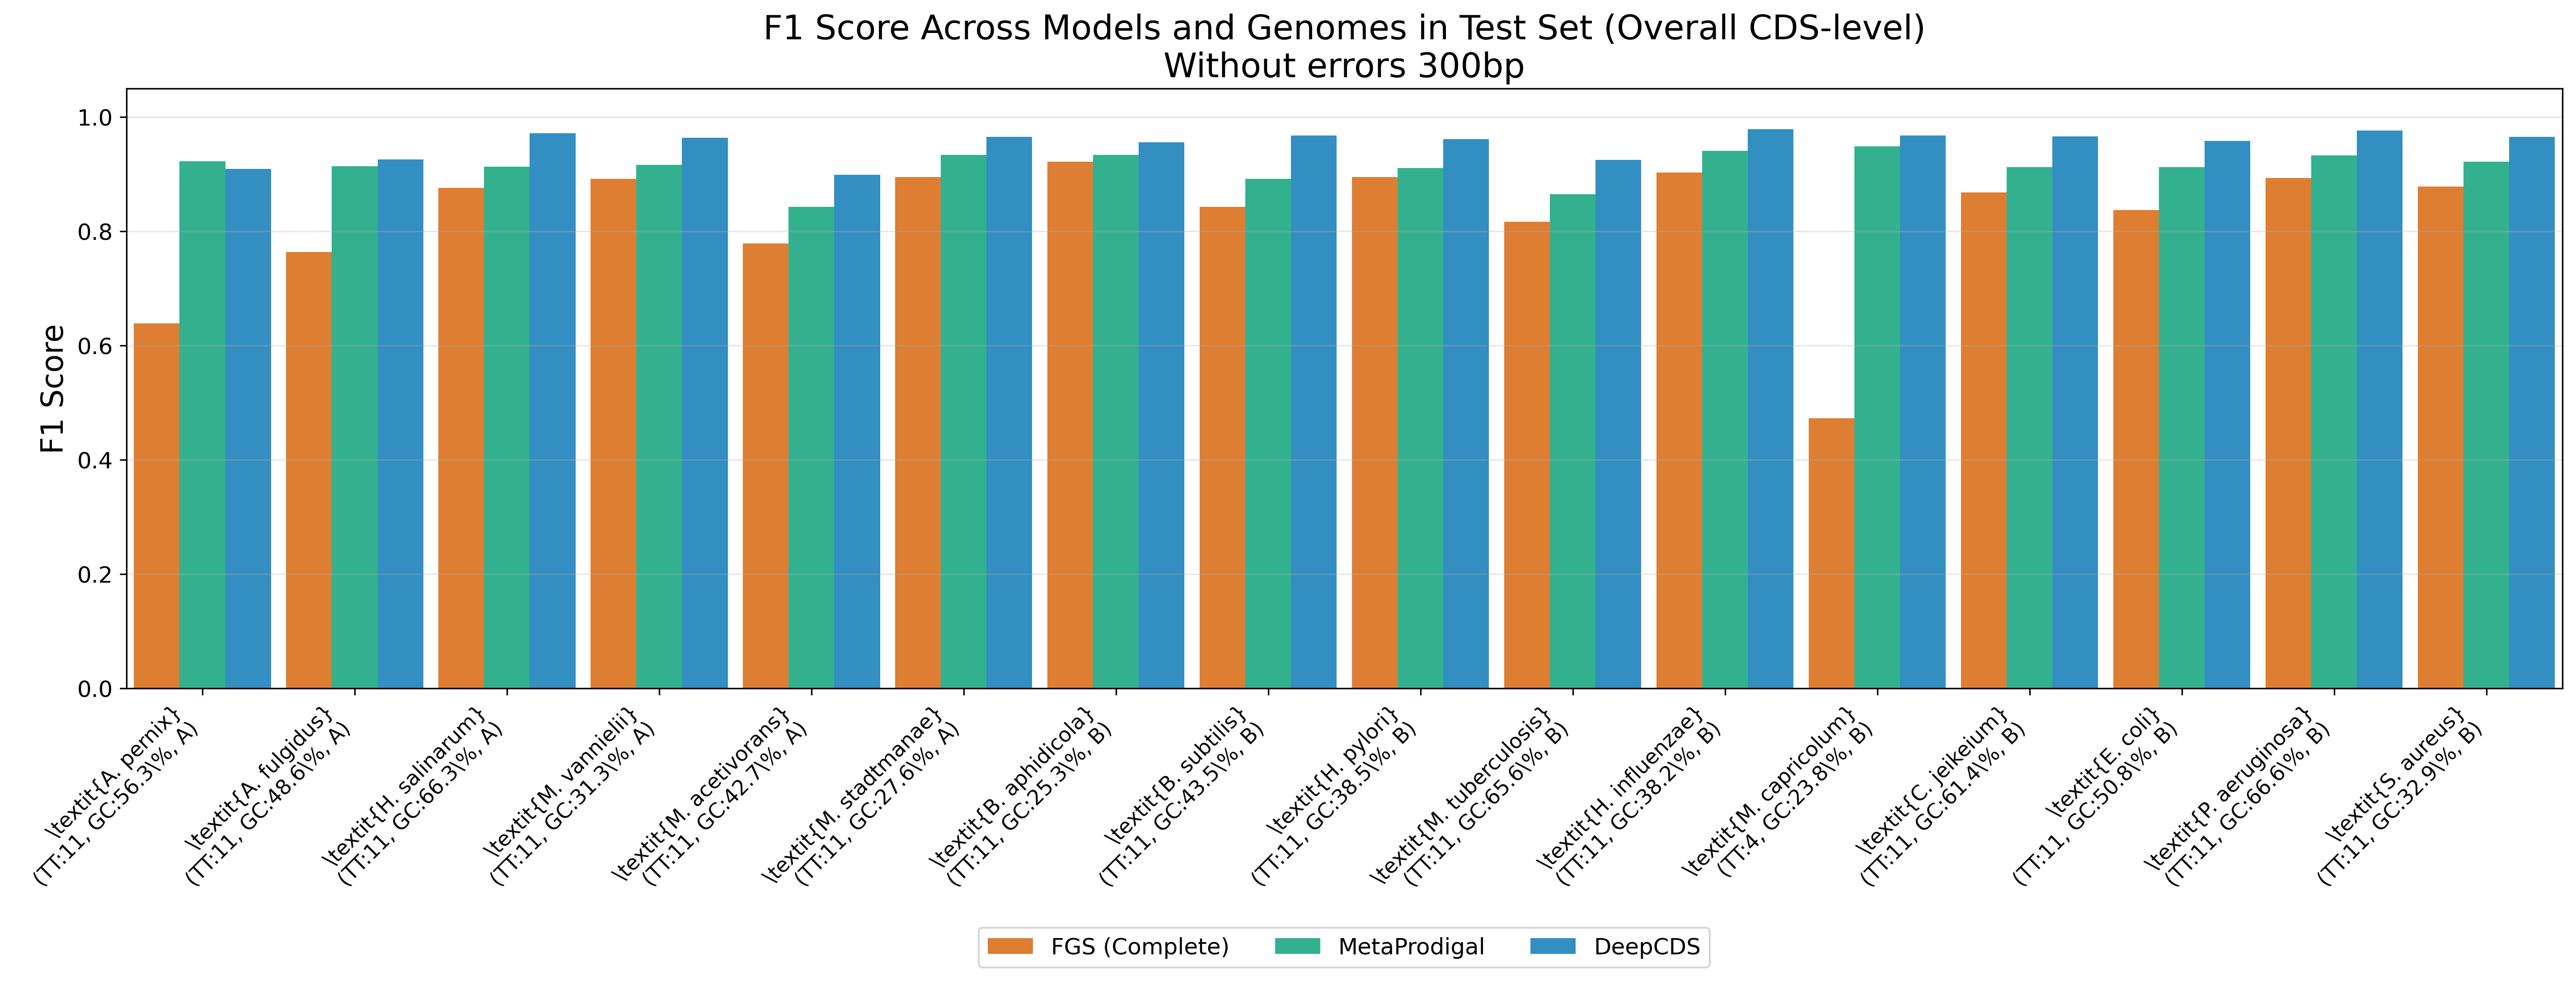

\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\toprule
Species & FGS (Complete) & MetaProdigal & DeepCDS \\
\midrule
\textit{A. pernix} & 0.639 & \textbf{0.923} & 0.909 \\
\textit{A. fulgidus} & 0.764 & 0.914 & \textbf{0.926} \\
\textit{H. salinarum} & 0.876 & 0.913 & \textbf{0.972} \\
\textit{M. vannielii} & 0.892 & 0.916 & \textbf{0.964} \\
\textit{M. acetivorans} & 0.779 & 0.843 & \textbf{0.899} \\
\textit{M. stadtmanae} & 0.895 & 0.934 & \textbf{0.965} \\
\textit{B. aphidicola} & 0.922 & 0.934 & \textbf{0.956} \\
\textit{B. subtilis} & 0.843 & 0.892 & \textbf{0.968} \\
\textit{H. pylori} & 0.895 & 0.911 & \textbf{0.961} \\
\textit{M. tuberculosis} & 0.817 & 0.865 & \textbf{0.925} \\
\textit{H. influenzae} & 0.903 & 0.941 & \textbf{0.979} \\
\textit{M. capricolum} & 0.473 & 0.949 & \textbf{0.968} \\
\textit{C. jeikeium} & 0.868 & 0.912 & \textbf{0.966} \\
\textit{E. coli} & 0.837 & 0.912 & \textbf{0.958} \\
\textit{P. aeruginosa} & 0.893 & 0.933 & \textbf{0.976} \\
\textit{S. a

In [105]:
for data_type in data_types:

    #Initialize
    performance_metrics_genomes_dict = {}

    for test_accession in test_accessions:
        read_names_list, testset_dict, prodigal_dict, \
        preds_fgs_dict, preds_deep_cds = load_in_processed_datasets(test_accession, data_type)

        #Store performance metrics for this genome
        performance_metrics_genomes_dict[test_accession] = {
            "fgs_complete": calculate_metrics(testset_dict, preds_fgs_dict, read_names_list, overlap_criteria),
            "prodigal": calculate_metrics(testset_dict, prodigal_dict, read_names_list, overlap_criteria),
            "deep_cds": calculate_metrics(testset_dict, preds_deep_cds, read_names_list, overlap_criteria)}
    
        
    plot_all_models_comparison('f1_score', performance_metrics_genomes_dict, data_type, genomes)
    #plot_all_models_comparison('recall', performance_metrics_genomes_dict, data_type, genomes)
    #plot_all_models_comparison('precision', performance_metrics_genomes_dict, data_type, genomes)

# Plot performance as a function of GC-content

In [106]:
def plot_metric_by_gc_content_boxplot(performance_metrics_dict, genome_metadata, metric_name, data_type,
                                       gc_bins=None, model_display_names=None, colors=None):
    """
    Plot boxplot of performance metric grouped by GC-content ranges.
    
    Args:
        performance_metrics_dict (dict): Dictionary with genome accessions as keys and model metrics as values
        genome_metadata (dict): Dictionary with genome metadata including gc_content
        metric_name (str): Name of the metric to plot (e.g., 'f1_score', 'precision', 'recall')
        data_type (str): Data type description for the plot title
        gc_bins (list, optional): List of bin edges for GC-content. Default: [0, 40, 50, 60, 100]
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for each model
    """
    if gc_bins is None:
        gc_bins = [0, 40, 50, 60, 100]
    
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_dict.values()))
    model_names = list(first_genome.keys())
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        colors = ['skyblue', 'orange', 'orchid', 'forestgreen', 'purple']
    
    # Create bin labels
    bin_labels = []
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] == 0:
            bin_labels.append(rf"$<${gc_bins[i+1]}\%")
        elif gc_bins[i+1] == 100:
            bin_labels.append(rf"$>${gc_bins[i]}\%")
        else:
            bin_labels.append(rf"{gc_bins[i]}--{gc_bins[i+1]}\%")
    
    # Organize data by GC bin and model
    data_by_bin_and_model = {label: {model: [] for model in model_names} for label in bin_labels}
    
    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue
        
        gc = genome_metadata[acc]['gc_content']
        
        # Find the appropriate bin
        bin_label = None
        for i in range(len(gc_bins) - 1):
            if gc_bins[i] <= gc < gc_bins[i + 1]:
                bin_label = bin_labels[i]
                break
        
        if bin_label is None:
            continue
        
        # Add metric values for each model
        for model in model_names:
            if model in metrics and metric_name in metrics[model]:
                data_by_bin_and_model[bin_label][model].append(metrics[model][metric_name])
    
    # Prepare data for boxplot
    n_models = len(model_names)
    n_bins = len(bin_labels)
    
    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(max(12, n_bins * 2), 7))
    
    # Position parameters
    width = 0.8 / n_models
    positions_base = np.arange(n_bins)
    
    # Create boxplots for each model
    for i, model in enumerate(model_names):
        positions = positions_base + (i - (n_models - 1) / 2) * width
        data = [data_by_bin_and_model[label][model] for label in bin_labels]
        
        bp = ax.boxplot(data, positions=positions, widths=width * 0.8,
                       patch_artist=True, manage_ticks=False)
        
        # Style the boxplot
        for patch in bp['boxes']:
            patch.set_facecolor(colors[i % len(colors)])
            patch.set_alpha(0.7)
        for median in bp['medians']:
            median.set_color('black')
    
    # Customize the plot
    ax.set_xlabel('GC-content Range')
    ax.set_ylabel(metric_name.replace("_", " ").title())
    #ax.set_title(f'{metric_name.replace("_", " ").title()} by GC-content Range\n{data_type}', fontsize=14)
    ax.set_xticks(positions_base)
    ax.set_xticklabels(bin_labels)
    
    # Add legend
    legend_patches = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[i % len(colors)], alpha=0.7) 
                     for i in range(n_models)]
    ax.legend(legend_patches, [display_names.get(m, m) for m in model_names],
             bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=min(4, n_models))
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.0, 1.05)
    
    # Add count annotations above each bin
    for i, label in enumerate(bin_labels):
        count = len(data_by_bin_and_model[label][model_names[0]])
        ax.text(i, 1, f'n={count}', ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    # plt.savefig(f'{data_type}_{metric_name}_by_gc_content_boxplot.png', dpi=500)
    # plt.savefig(f'{data_type}_{metric_name}_by_gc_content_boxplot.svg', dpi=500)
    plt.show()

In [107]:
def plot_metric_by_gc_content_sina(performance_metrics_dict, genome_metadata, metric_name, data_type,
                                   gc_bins=None, model_display_names=None, colors=None, 
                                   overlay='none'):
    """
    Plot sina plot of performance metric grouped by GC-content ranges.
    Sina plots show individual points jittered by local density.
    
    Args:
        performance_metrics_dict (dict): Dictionary with genome accessions as keys and model metrics as values
        genome_metadata (dict): Dictionary with genome metadata including gc_content
        metric_name (str): Name of the metric to plot (e.g., 'f1_score', 'precision', 'recall')
        data_type (str): Data type description for the plot title
        gc_bins (list, optional): List of bin edges for GC-content. Default: [0, 40, 50, 60, 100]
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for each model
        overlay (str): Type of overlay - 'none', 'boxplot', or 'violin'. Default: 'none'
    """
    if gc_bins is None:
        gc_bins = [0, 40, 50, 60, 100]
    
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_dict.values()))
    model_names = list(first_genome.keys())
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        colors = ['orange', 'skyblue', 'orchid', 'forestgreen', 'purple']
    
    # Create bin labels
    bin_labels = []
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] == 0:
            bin_labels.append(rf"$<${gc_bins[i+1]}\%")
        elif gc_bins[i+1] == 100:
            bin_labels.append(rf"$>${gc_bins[i]}\%")
        else:
            bin_labels.append(rf"{gc_bins[i]}--{gc_bins[i+1]}\%")
    
    # Organize data by GC bin and model
    data_by_bin_and_model = {label: {model: [] for model in model_names} for label in bin_labels}
    
    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue
        
        gc = genome_metadata[acc]['gc_content']
        
        # Find the appropriate bin
        bin_label = None
        for i in range(len(gc_bins) - 1):
            if gc_bins[i] <= gc < gc_bins[i + 1]:
                bin_label = bin_labels[i]
                break
        
        if bin_label is None:
            continue
        
        # Add metric values for each model
        for model in model_names:
            if model in metrics and metric_name in metrics[model]:
                data_by_bin_and_model[bin_label][model].append(metrics[model][metric_name])
    
    # Create the plot
    n_models = len(model_names)
    n_bins = len(bin_labels)
    
    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(max(12, n_bins * 2), 7))
    
    # Position parameters
    width = 0.8 / n_models
    positions_base = np.arange(n_bins)
    
    def sina_jitter(values, max_width=0.4):
        """Calculate jitter based on local density using KDE."""
        if len(values) < 2:
            return np.zeros(len(values))
        
        values = np.array(values)
        try:
            kde = stats.gaussian_kde(values)
            densities = kde(values)
            # Normalize densities to [0, 1]
            densities = densities / densities.max()
            # Random jitter scaled by density
            jitter = np.random.uniform(-1, 1, len(values)) * densities * max_width
        except:
            # Fallback to simple random jitter if KDE fails
            jitter = np.random.uniform(-max_width, max_width, len(values))
        
        return jitter
    
    # Plot for each model
    for i, model in enumerate(model_names):
        base_pos = positions_base + (i - (n_models - 1) / 2) * width
        
        for j, label in enumerate(bin_labels):
            values = data_by_bin_and_model[label][model]
            if not values:
                continue
            
            values = np.array(values)
            jitter = sina_jitter(values, max_width=width * 0.4)
            x_positions = base_pos[j] + jitter
            
            # Plot individual points
            ax.scatter(x_positions, values, 
                      c=colors[i % len(colors)], 
                      alpha=0.6, s=30, edgecolors='white', linewidth=0.5,
                      label=display_names.get(model, model) if j == 0 else "")
        
        # Add overlay based on type
        data = [data_by_bin_and_model[label][model] for label in bin_labels]
        
        if overlay == 'boxplot':
            bp = ax.boxplot(data, positions=base_pos, widths=width * 0.6,
                           patch_artist=True, manage_ticks=False, showfliers=False)
            
            for patch in bp['boxes']:
                patch.set_facecolor('none')
                patch.set_edgecolor(colors[i % len(colors)])
                patch.set_linewidth(1.5)
            for median in bp['medians']:
                median.set_color(colors[i % len(colors)])
                median.set_linewidth(2)
            for whisker in bp['whiskers']:
                whisker.set_color(colors[i % len(colors)])
                whisker.set_linewidth(1.5)
            for cap in bp['caps']:
                cap.set_color(colors[i % len(colors)])
                cap.set_linewidth(1.5)
        
        elif overlay == 'violin':
            # Only create violin for bins with enough data
            valid_data = []
            valid_positions = []
            for j, d in enumerate(data):
                if len(d) >= 2:  # Need at least 2 points for violin
                    valid_data.append(d)
                    valid_positions.append(base_pos[j])
            
            if valid_data:
                parts = ax.violinplot(valid_data, positions=valid_positions, 
                                     widths=width * 0.8, showmeans=False, 
                                     showmedians=True, showextrema=False)
                
                for pc in parts['bodies']:
                    pc.set_facecolor(colors[i % len(colors)])
                    pc.set_alpha(0.3)
                    pc.set_edgecolor(colors[i % len(colors)])
                    pc.set_linewidth(1.5)
                
                parts['cmedians'].set_color(colors[i % len(colors)])
                parts['cmedians'].set_linewidth(2)
    
    # Customize the plot
    ax.set_xlabel('GC-content Range', fontsize=12)
    ax.set_ylabel(metric_name.replace("_", " ").title(), fontsize=12)
    ax.set_title(f'{metric_name.replace("_", " ").title()} by GC-content Range (Sina Plot)\n{data_type}', fontsize=14)
    ax.set_xticks(positions_base)
    ax.set_xticklabels(bin_labels)
    
    # Add legend (remove duplicates)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(),
             bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=min(4, n_models))
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.0, 1.05)
    
    # Add count annotations
    for i, label in enumerate(bin_labels):
        count = len(data_by_bin_and_model[label][model_names[0]])
        ax.text(i, 1.02, f'n={count}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

In [108]:
_expected_cache_files = ["all_performance_metrics_dict.pkl"]

_should_compute = True

if LOAD_PROCESSED_DATA:
    _cache_ok = os.path.isdir(_cache_dir) and all(
        os.path.isfile(os.path.join(_cache_dir, f)) for f in _expected_cache_files
    )
    if _cache_ok:
        data_type = data_types[-1]
        print(f"Loading pre-computed results from:\n  {_cache_dir}")
        with open(os.path.join(_cache_dir, "all_performance_metrics_dict.pkl"), "rb") as f:
            all_performance_metrics_dict = pickle.load(f)
        _should_compute = False
    else:
        print(f"Warning: No cached data found for overlap_criteria={overlap_criteria}.")
        print(f"  Expected cache path: {_cache_dir}")
        print("  Falling back to full data processing...")

if _should_compute:
    for data_type in data_types:
    
        # Calculate performance metrics for ALL test accessions
        all_performance_metrics_dict = {}
    
        for test_accession in tqdm(all_test_accessions, desc=f"Processing {data_type}"):
            try:
                read_names_list, testset_dict, prodigal_dict, \
                preds_fgs_dict, preds_deep_cds = load_in_processed_datasets(test_accession, data_type)
            
                all_performance_metrics_dict[test_accession] = {
                    "fgs_complete": calculate_metrics(testset_dict, preds_fgs_dict, read_names_list, overlap_criteria),
                    "prodigal": calculate_metrics(testset_dict, prodigal_dict, read_names_list, overlap_criteria),
                    "deep_cds": calculate_metrics(testset_dict, preds_deep_cds, read_names_list, overlap_criteria)
                }
            except Exception as e:
                print(f"Error processing {test_accession}: {e}")
                continue

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/without_errors/organisms_families_gc_content/oc_1


In [109]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "all_performance_metrics_dict": all_performance_metrics_dict,
    }
    for _name, _obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{_name}.pkl"), "wb") as f:
            pickle.dump(_obj, f)
    print(f"Results saved to {_cache_dir}")

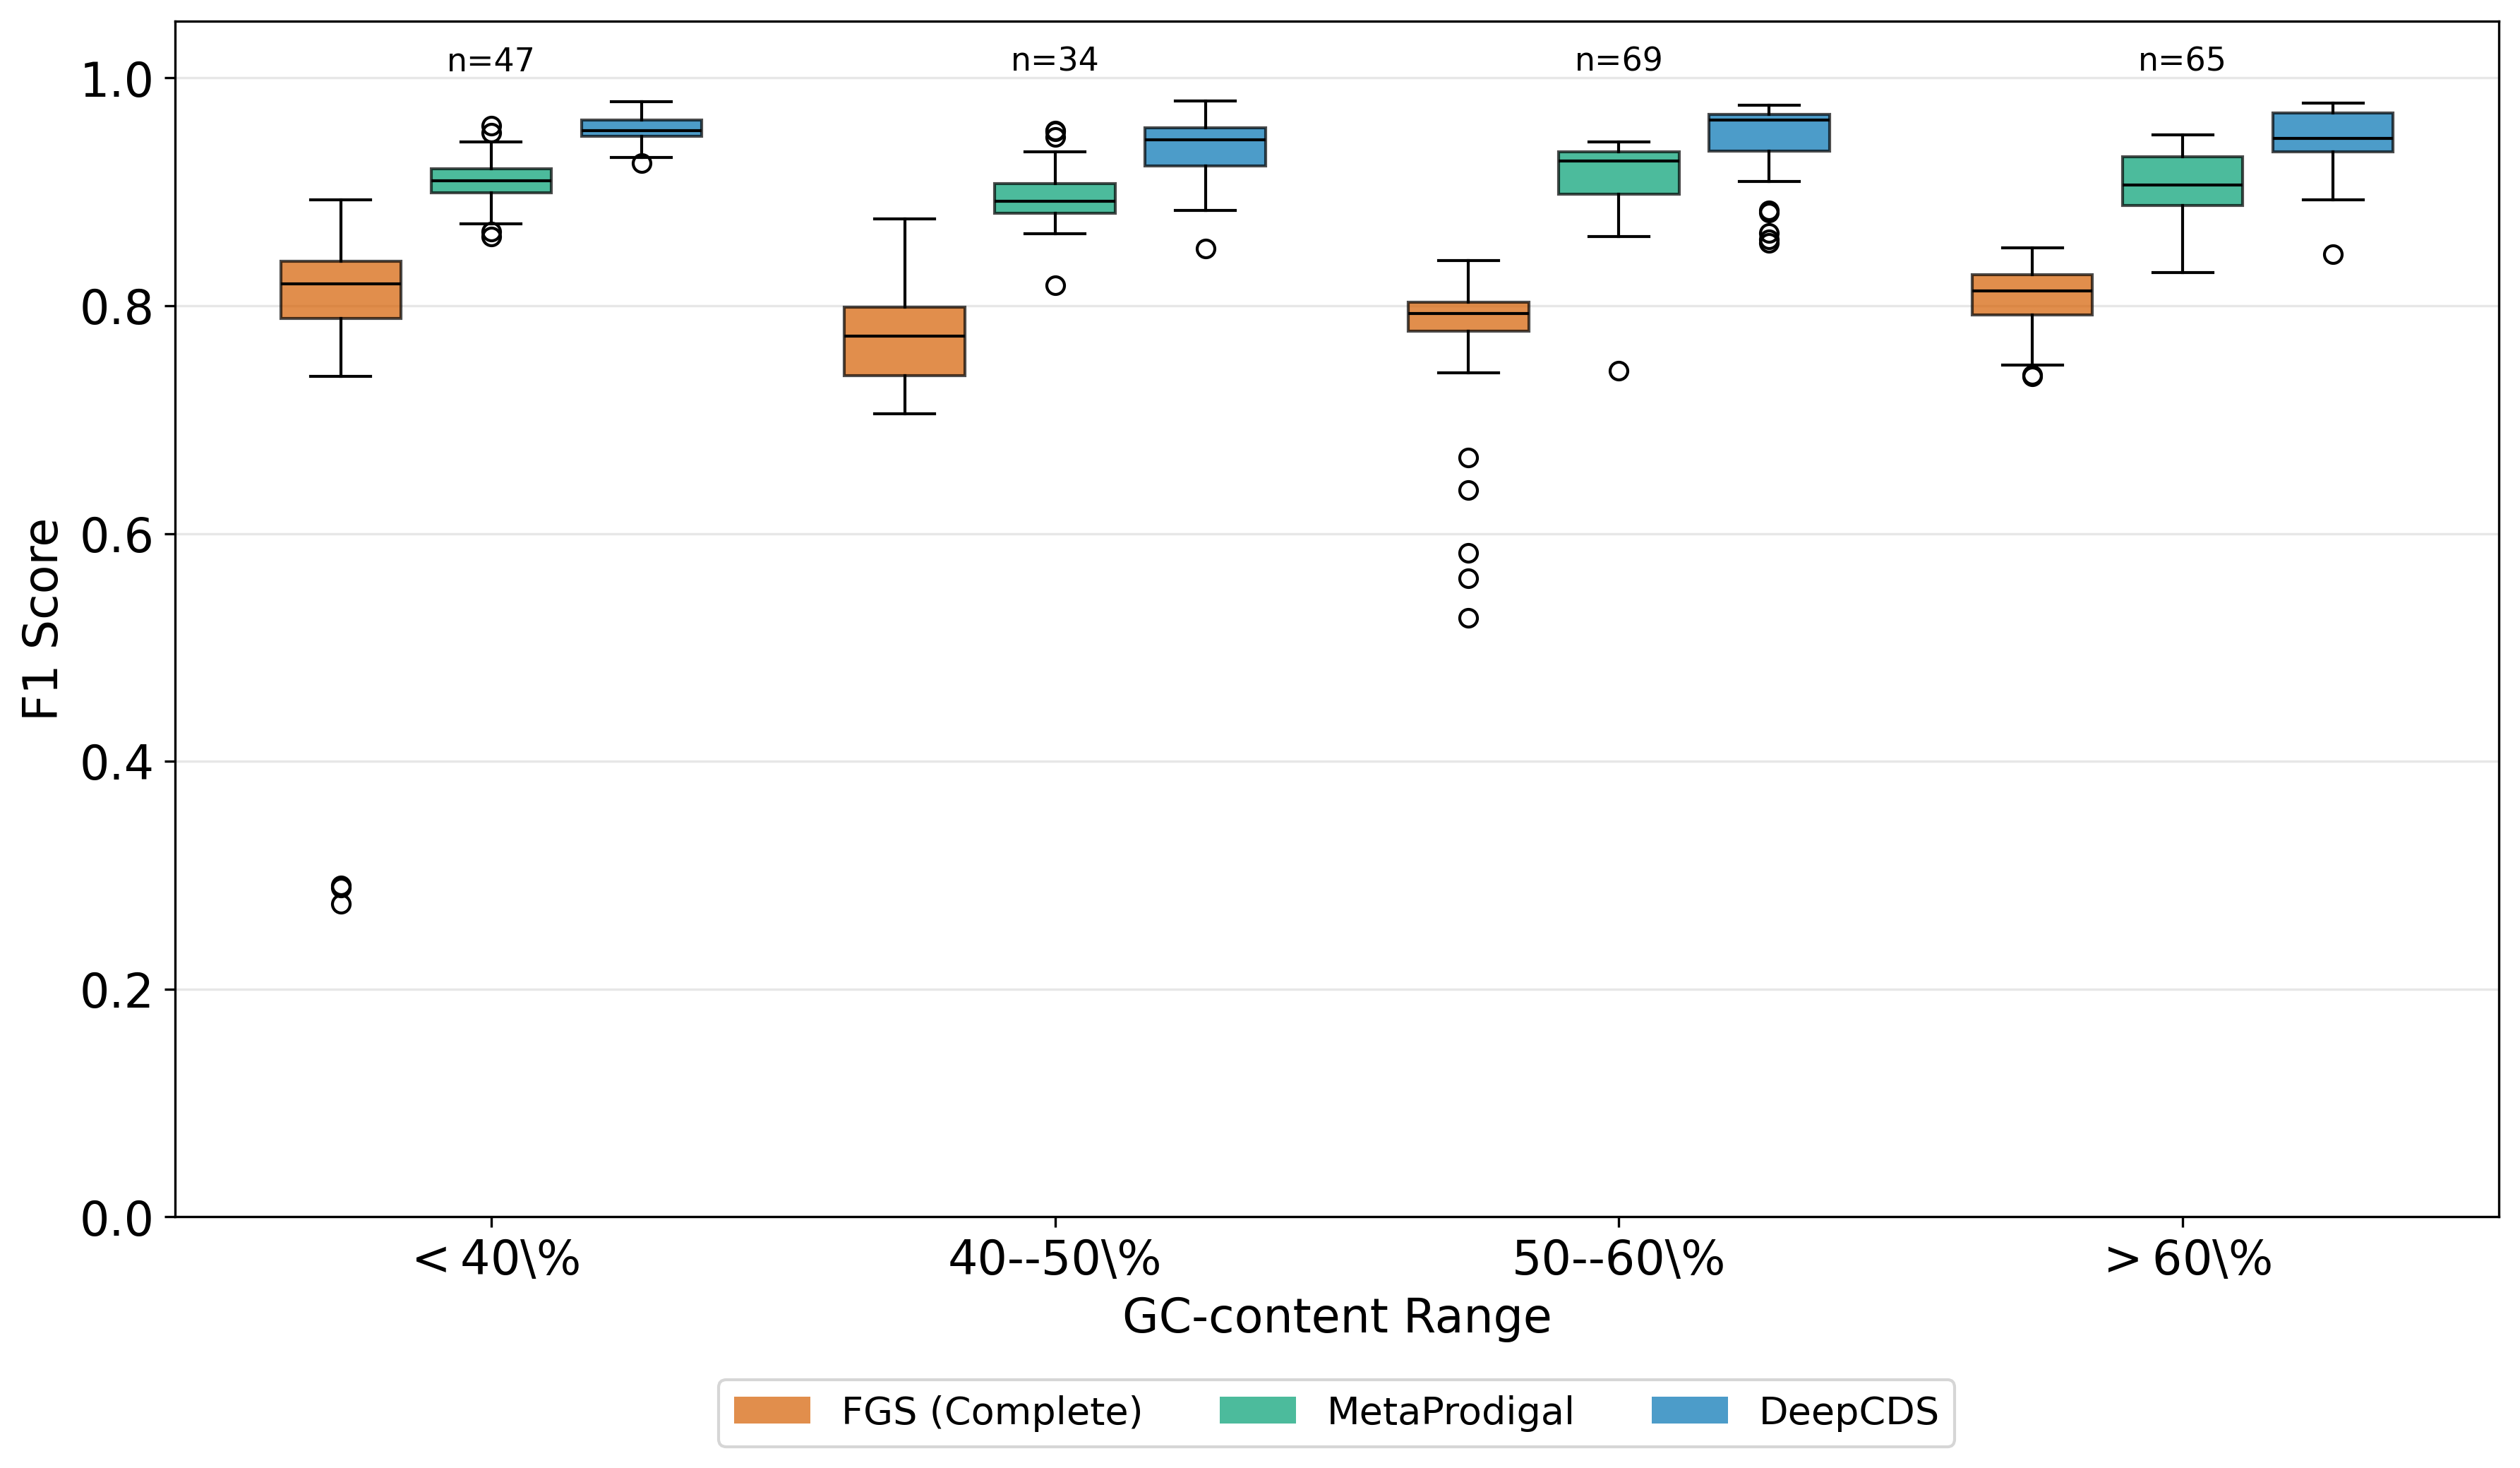

In [110]:
model_order = ["fgs_complete", "prodigal", "deep_cds"]
model_display_names_ordered = {k: MODEL_DISPLAY_NAMES[k] for k in model_order}
custom_colors_ordered = [MODEL_COLORS[k] for k in model_order]

def reorder_metrics(metrics_dict, order):
    reordered = {}
    for acc, models in metrics_dict.items():
        reordered[acc] = {model: models[model] for model in order if model in models}
    return reordered

all_performance_metrics_ordered = reorder_metrics(all_performance_metrics_dict, model_order)

# Plot boxplots by GC-content
plot_metric_by_gc_content_boxplot(all_performance_metrics_dict, all_genomes, 'f1_score', data_type,
                                  model_display_names=model_display_names_ordered, colors=custom_colors_ordered)

# Plot performance as a function of GC-content as scatterplot(aggregated to GC-content category, not genome-level)

In [111]:
def plot_metric_by_gc_content_bars(performance_metrics_dict, genome_metadata, metric_name, data_type,
                                    gc_bins=None, model_display_names=None, colors=None):
    """
    Plot barplot of aggregated performance metric by GC-content ranges.
    Aggregates all predictions within each GC bin to compute a single metric.
    
    Args:
        performance_metrics_dict (dict): Dictionary with genome accessions as keys and model metrics as values
        genome_metadata (dict): Dictionary with genome metadata including gc_content
        metric_name (str): Name of the metric to plot (e.g., 'f1_score', 'precision', 'recall')
        data_type (str): Data type description for the plot title
        gc_bins (list, optional): List of bin edges for GC-content. Default: [0, 40, 50, 60, 100]
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for each model
    """
    if gc_bins is None:
        gc_bins = [0, 40, 50, 60, 100]
    
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_dict.values()))
    model_names = list(first_genome.keys())
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        colors = ['orange', 'skyblue', 'orchid', 'forestgreen', 'purple']
    
    # Create bin labels
    bin_labels = []
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] == 0:
            bin_labels.append(rf"$<${gc_bins[i+1]}\%")
        elif gc_bins[i+1] == 100:
            bin_labels.append(rf"$>${gc_bins[i]}\%")
        else:
            bin_labels.append(rf"{gc_bins[i]}--{gc_bins[i+1]}\%")
    
    # Aggregate raw counts by GC bin and model
    aggregated_counts = {label: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'count': 0} 
                                  for model in model_names} 
                         for label in bin_labels}
    
    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue
        
        gc = genome_metadata[acc]['gc_content']
        
        # Find the appropriate bin
        bin_label = None
        for i in range(len(gc_bins) - 1):
            if gc_bins[i] <= gc < gc_bins[i + 1]:
                bin_label = bin_labels[i]
                break
        
        if bin_label is None:
            continue
        
        # Aggregate counts for each model
        for model in model_names:
            if model in metrics:
                aggregated_counts[bin_label][model]['tp'] += metrics[model].get('total_true_positives', 0)
                aggregated_counts[bin_label][model]['fp'] += metrics[model].get('total_false_positives', 0)
                aggregated_counts[bin_label][model]['fn'] += metrics[model].get('total_false_negatives', 0)
                aggregated_counts[bin_label][model]['count'] += 1
    
    # Calculate aggregated metrics for each bin and model
    aggregated_metrics = {model: [] for model in model_names}
    genome_counts = []
    
    for i, label in enumerate(bin_labels):
        genome_counts.append(aggregated_counts[label][model_names[0]]['count'])
        
        for model in model_names:
            counts = aggregated_counts[label][model]
            tp, fp, fn = counts['tp'], counts['fp'], counts['fn']
            
            # Calculate metrics from aggregated counts
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            if metric_name == 'f1_score':
                aggregated_metrics[model].append(f1)
            elif metric_name == 'precision':
                aggregated_metrics[model].append(precision)
            elif metric_name == 'recall':
                aggregated_metrics[model].append(recall)
    
    # Create the barplot
    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(12, 7))
    
    n_models = len(model_names)
    n_bins = len(bin_labels)
    x = np.arange(n_bins)
    width = 0.8 / n_models
    
    # Create bars for each model
    for i, model in enumerate(model_names):
        x_pos = x - (n_models - 1) * width / 2 + i * width
        bars = ax.bar(x_pos, aggregated_metrics[model], width,
                     label=display_names.get(model, model),
                     color=colors[i % len(colors)], alpha=0.8)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Customize the plot
    ax.set_xlabel('GC-content Range', fontsize=12)
    ax.set_ylabel(metric_name.replace("_", " ").title(), fontsize=12)
    ax.set_title(f'Aggregated {metric_name.replace("_", " ").title()} by GC-content Range\n{data_type}', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels)
    
    # Add genome count annotations
    for i, count in enumerate(genome_counts):
        ax.text(i, ax.get_ylim()[1] * 0.99, f'n={count}', ha='center', va='top', fontsize=10)
    
    # Add legend
    ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=min(4, n_models))
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.0, 1.05)
    
    plt.tight_layout()
    plt.show()

In [112]:
def plot_metric_per_family_bars(performance_metrics_dict, genome_metadata, metric_name, data_type,
                                 model_display_names=None, colors=None, min_genomes=1):
    """
    Plot barplot of aggregated performance metric per family, with error bars showing
    the range (min–max) of per-genome F1 scores within each family.

    Bar height = metric computed on all aggregated TP/FP/FN within the family.
    Error bars = [bar_height - min_per_genome, max_per_genome - bar_height].

    Args:
        performance_metrics_dict (dict): Dictionary with genome accessions as keys and model metrics as values
        genome_metadata (dict): Dictionary with genome metadata including family
        metric_name (str): Name of the metric to plot (e.g., 'f1_score', 'precision', 'recall')
        data_type (str): Data type description for the plot title
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for each model
        min_genomes (int): Minimum number of genomes required to include a family. Default: 1
    """
    # Get model names from the first genome entry
    first_genome = next(iter(performance_metrics_dict.values()))
    model_names = list(first_genome.keys())

    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names

    # Set up colors
    if colors is None:
        colors = ['orange', 'skyblue', 'orchid', 'forestgreen', 'purple']

    # Get all unique families
    families = set()
    for acc in performance_metrics_dict.keys():
        if acc in genome_metadata:
            families.add(genome_metadata[acc]['family'])

    # Aggregate raw counts AND collect per-genome scores by family and model
    aggregated_counts = {family: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'count': 0}
                                   for model in model_names}
                         for family in families}
    per_genome_scores = {family: {model: [] for model in model_names}
                         for family in families}

    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue

        family = genome_metadata[acc]['family']

        for model in model_names:
            if model in metrics:
                aggregated_counts[family][model]['tp'] += metrics[model].get('total_true_positives', 0)
                aggregated_counts[family][model]['fp'] += metrics[model].get('total_false_positives', 0)
                aggregated_counts[family][model]['fn'] += metrics[model].get('total_false_negatives', 0)
                aggregated_counts[family][model]['count'] += 1
                # Collect the per-genome score for error bar computation
                if metric_name in metrics[model]:
                    per_genome_scores[family][model].append(metrics[model][metric_name])

    # Filter families by minimum genome count
    valid_families = [f for f in families if aggregated_counts[f][model_names[0]]['count'] >= min_genomes]

    # Helper to compute metric from aggregated counts
    def _metric_from_counts(tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        if metric_name == 'f1_score':
            return f1
        elif metric_name == 'precision':
            return precision
        elif metric_name == 'recall':
            return recall
        return f1

    # Sort families by the first model's aggregated metric (descending)
    family_scores = []
    for family in valid_families:
        counts = aggregated_counts[family][model_names[0]]
        score = _metric_from_counts(counts['tp'], counts['fp'], counts['fn'])
        family_scores.append((family, score))
    sorted_families = [f for f, _ in sorted(family_scores, key=lambda x: x[1], reverse=True)]

    # Build per-family aggregated metrics and error bounds
    aggregated_metrics = {model: [] for model in model_names}
    error_low  = {model: [] for model in model_names}   # bar_height - min
    error_high = {model: [] for model in model_names}   # max - bar_height
    genome_counts = []
    family_labels = []

    for family in sorted_families:
        genome_counts.append(aggregated_counts[family][model_names[0]]['count'])
        family_labels.append(family)

        for model in model_names:
            counts = aggregated_counts[family][model]
            agg_val = _metric_from_counts(counts['tp'], counts['fp'], counts['fn'])
            aggregated_metrics[model].append(agg_val)

            scores = per_genome_scores[family][model]
            if len(scores) > 1:
                lo = agg_val - min(scores)
                hi = max(scores) - agg_val
            else:
                lo, hi = 0.0, 0.0
            error_low[model].append(max(lo, 0.0))   # guard against tiny float negatives
            error_high[model].append(max(hi, 0.0))

    # Create the barplot
    n_families = len(sorted_families)
    n_models = len(model_names)

    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(max(18, n_families * 1.2), 8))

    x = np.arange(n_families)
    width = 0.8 / n_models

    for i, model in enumerate(model_names):
        x_pos = x - (n_models - 1) * width / 2 + i * width
        yerr = np.array([error_low[model], error_high[model]])
        ax.bar(x_pos, aggregated_metrics[model], width,
               label=display_names.get(model, model),
               color=colors[i % len(colors)], alpha=0.8,
               yerr=yerr, capsize=3,
               error_kw=dict(elinewidth=0.8, ecolor='black', capthick=0.8))

    # Customize the plot
    ax.set_ylabel(metric_name.replace("_", " ").title(), fontsize=16)
    #ax.set_title(f'Aggregated {metric_name.replace("_", " ").title()} per Family\n{data_type}', fontsize=18)
    ax.set_xticks(x)

    x_labels = [f"{fam}\n(n={cnt})" for fam, cnt in zip(family_labels, genome_counts)]
    ax.set_xticklabels(x_labels, rotation=45, ha='right')

    ax.legend(bbox_to_anchor=(0.5, -0.3), loc='upper center', ncol=len(model_names))
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.0, 1.05)

    plt.tight_layout()
    # plt.savefig(f'{metric_name}_per_family_{data_type}.svg', dpi=500)
    # plt.savefig(f'{metric_name}_per_family_{data_type}.png', dpi=500)
    plt.show()

    return sorted_families, aggregated_metrics


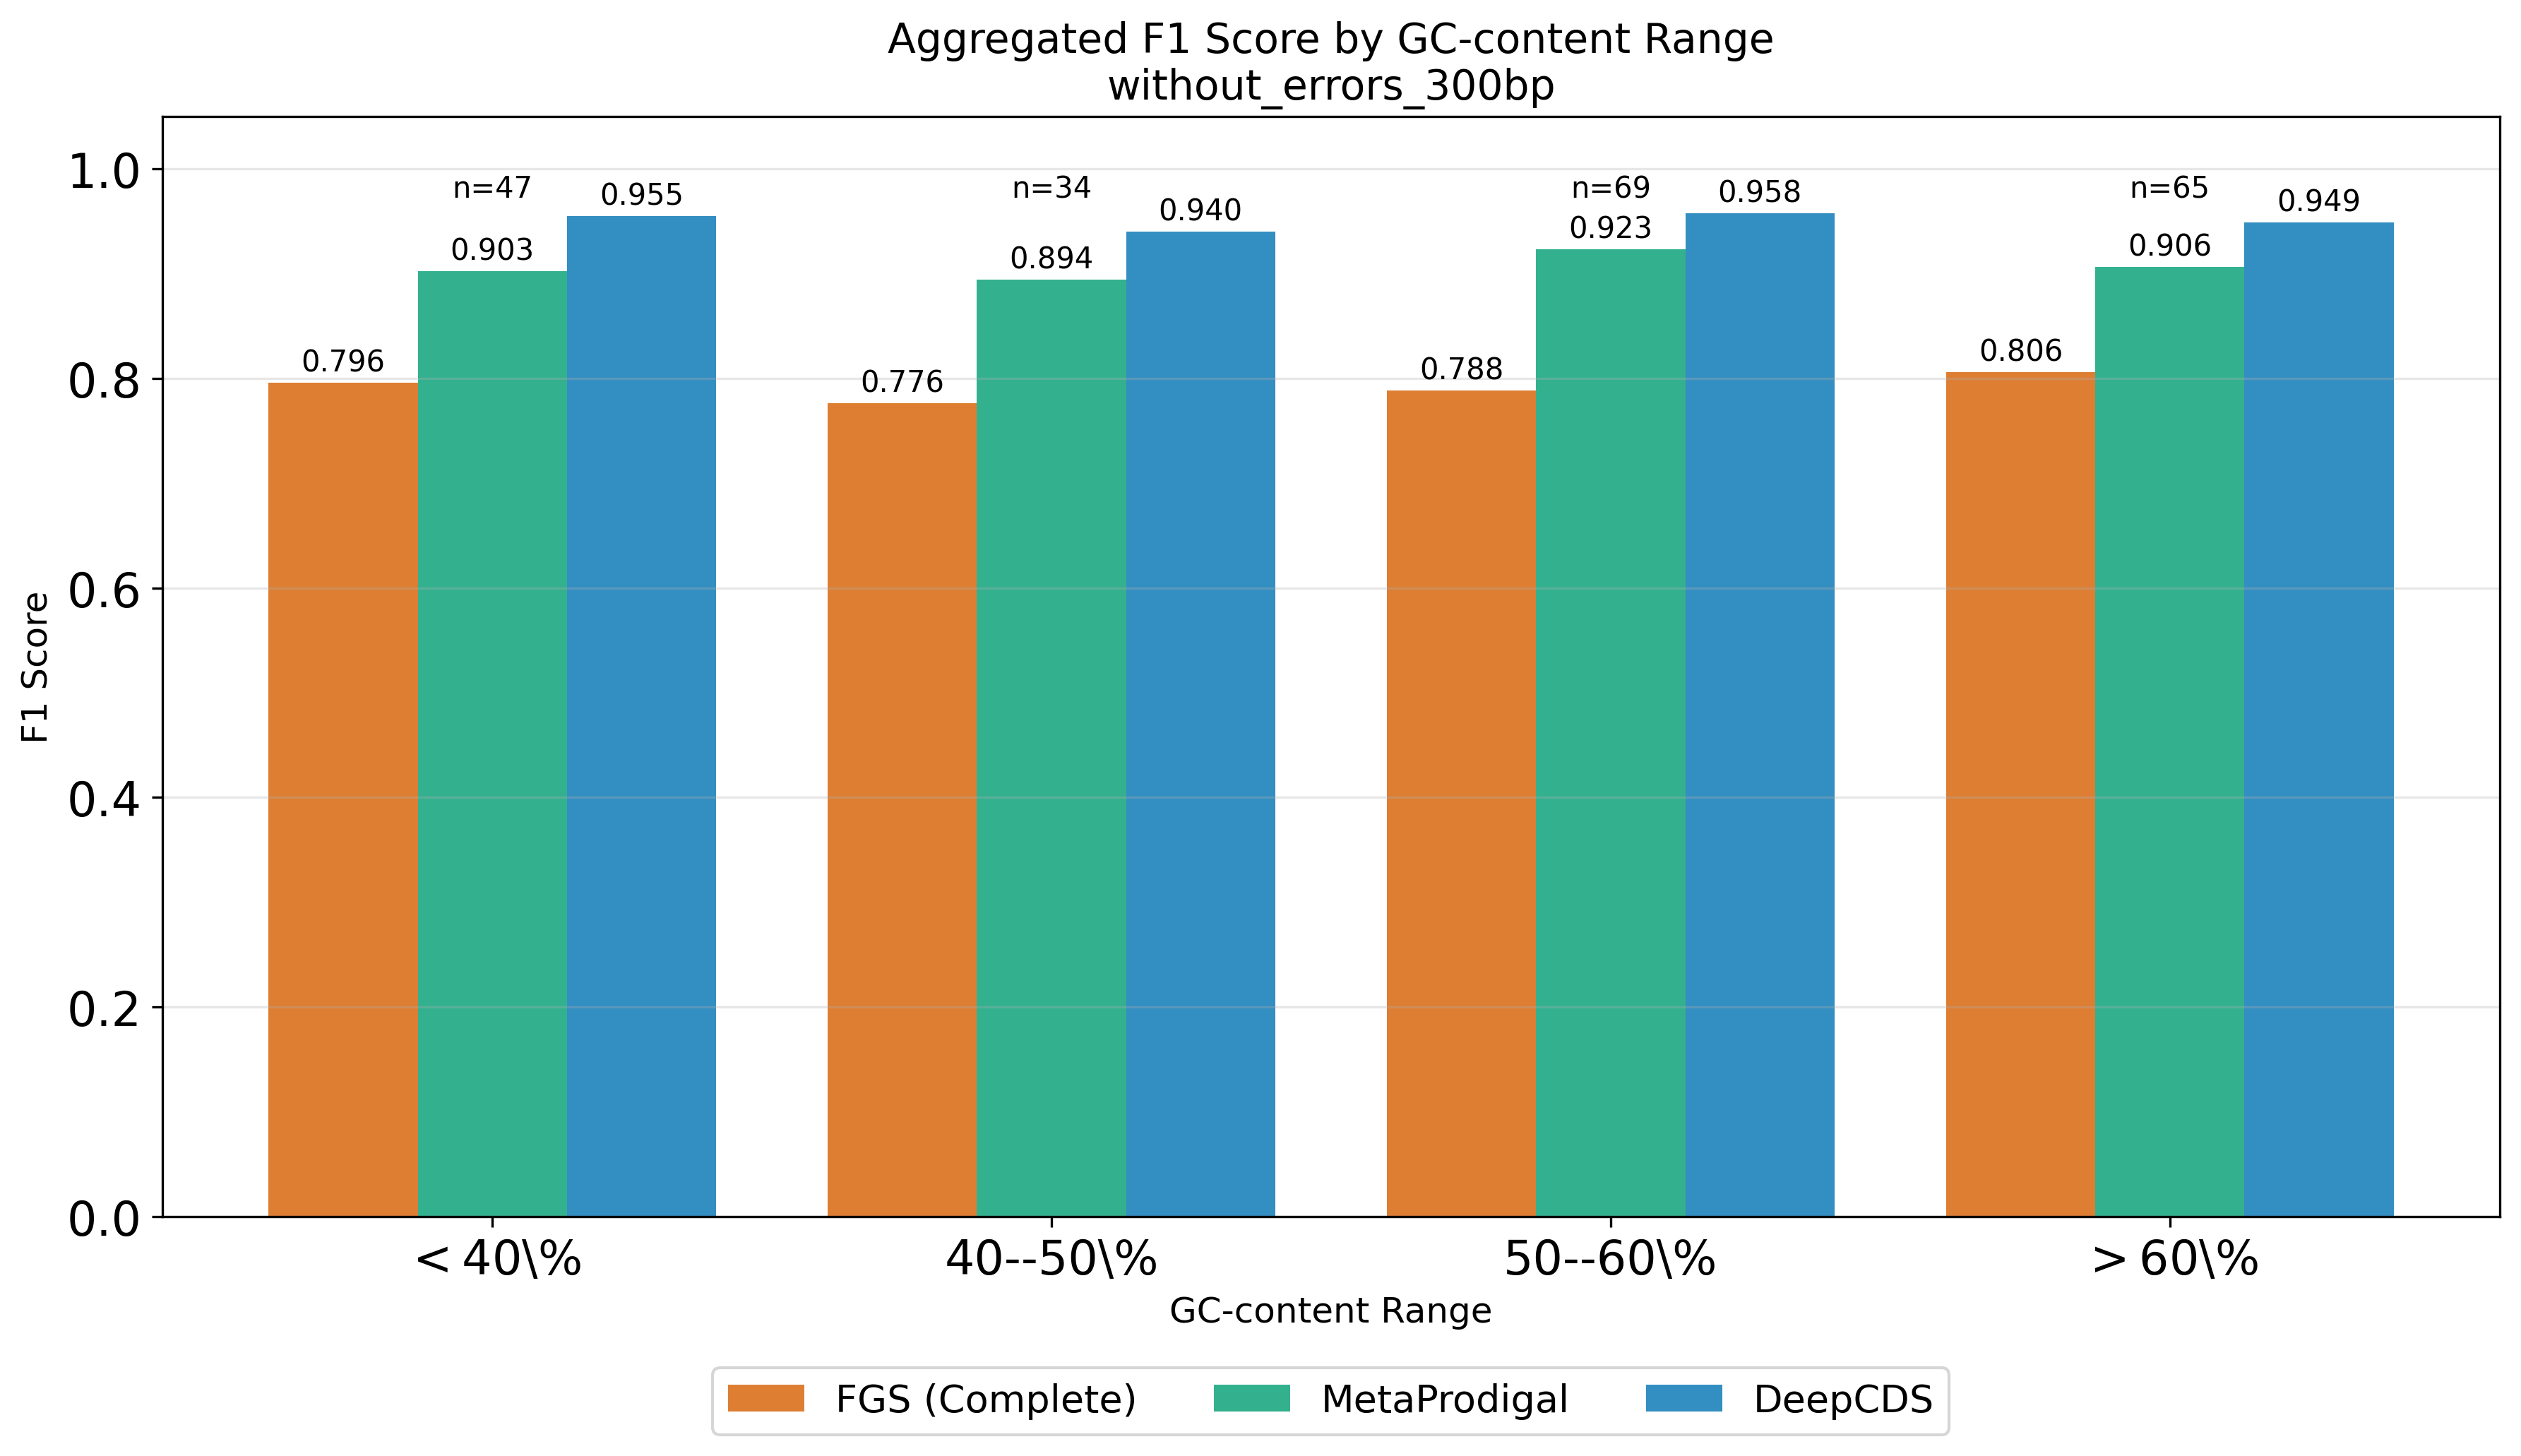

In [113]:
for data_type in data_types:
    plot_metric_by_gc_content_bars(all_performance_metrics_ordered, all_genomes, 'f1_score', data_type,
                                   model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_by_gc_content_bars(all_performance_metrics_ordered, all_genomes, 'recall', data_type,
    #                               model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_by_gc_content_bars(all_performance_metrics_ordered, all_genomes, 'precision', data_type,
    #                               model_display_names=model_display_names_ordered, colors=custom_colors_ordered)

## Per-genome scatterplot: GC-content vs. F1 score

In [114]:
def plot_gc_vs_metric_scatter(performance_metrics_dict, genome_metadata, metric_name, data_type,
                               model_order=None, model_display_names=None, colors=None,
                               max_cols=4):
    """
    Scatterplot of GC-content vs. per-genome performance metric, one panel per model.
    Reports Spearman correlation in each panel.

    Args:
        performance_metrics_dict (dict): {accession: {model: {metric: value, ...}}}
        genome_metadata (dict): {accession: {gc_content: float, domain: str, ...}}
        metric_name (str): metric key, e.g. 'f1_score'
        data_type (str): label for the figure title / save filename
        model_order (list, optional): order of models to plot
        model_display_names (dict, optional): {model_key: display_name}
        colors (list, optional): list of bar colors per model
        max_cols (int): maximum number of panels per row (default 4)
    """
    if model_order is None:
        model_order = list(next(iter(performance_metrics_dict.values())).keys())
    if model_display_names is None:
        model_display_names = {m: m for m in model_order}
    if colors is None:
        colors = ['#D55E00', '#009E73', '#CC79A7', '#0072B2']

    # Build aligned arrays
    accessions = [acc for acc in performance_metrics_dict
                  if acc in genome_metadata and genome_metadata[acc].get('gc_content') is not None]

    gc_arr  = np.array([genome_metadata[acc]['gc_content'] for acc in accessions])
    domains = np.array([genome_metadata[acc].get('domain', 'Unknown') for acc in accessions])

    domain_colors = {'Bacteria': '#0072B2', 'Archaea': '#D55E00'}
    domain_labels = sorted(set(domains))

    n_models = len(model_order)
    n_cols = min(n_models, max_cols)
    n_rows = math.ceil(n_models / n_cols)

    matplotlib.rcParams['text.usetex'] = False
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 4.2),
                             sharey=True, constrained_layout=True)
    axes_flat = np.array(axes).flatten()

    for idx, (model, color) in enumerate(zip(model_order, colors)):
        ax = axes_flat[idx]
        f1_arr = np.array([
            performance_metrics_dict[acc][model].get(metric_name, np.nan)
            for acc in accessions
        ])
        valid = ~np.isnan(f1_arr)
        gc_v, f1_v, dom_v = gc_arr[valid], f1_arr[valid], domains[valid]

        # Points coloured by domain
        for domain in domain_labels:
            mask = dom_v == domain
            ax.scatter(gc_v[mask], f1_v[mask],
                       c=domain_colors.get(domain, 'grey'),
                       s=10, alpha=0.8, linewidths=0, label=domain)

        # Linear regression line
        m_reg, b_reg = np.polyfit(gc_v, f1_v, 1)
        x_line = np.linspace(gc_v.min(), gc_v.max(), 200)
        ax.plot(x_line, m_reg * x_line + b_reg, color='black', lw=1.2, zorder=5)

        # Spearman correlation per domain — bottom right corner
        annotation_lines = []
        for domain in domain_labels:
            mask = dom_v == domain
            if mask.sum() >= 3:
                rho_d, p_d = spearmanr(gc_v[mask], f1_v[mask])
                p_txt = r'$<$0.001' if p_d < 0.001 else f'= {p_d:.3f}'
                annotation_lines.append((rf'$\rho$ = {rho_d:.2f}, $p$ {p_txt}', domain_colors.get(domain, 'grey')))

        for line_idx, (text, col) in enumerate(reversed(annotation_lines)):
            ax.annotate(
                text,
                xy=(0.97, 0.05 + line_idx * 0.09), xycoords='axes fraction',
                fontsize=8, va='bottom', ha='right', color=col
            )

        ax.set_title(model_display_names.get(model, model), fontsize=14)
        ax.set_xticks(range(20, 75, 10))
        ax.tick_params(axis='x', labelsize=11)

    # Hide any unused axes
    for idx in range(n_models, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    # Y-axis label on leftmost column
    for row in range(n_rows):
        axes_flat[row * n_cols].set_ylabel(metric_name.replace('_', ' ').title(), fontsize=14)

    fig.supxlabel('GC content', fontsize=14)

    # Shared domain legend — centred at the bottom
    legend_handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=domain_colors.get(d, 'grey'),
               markersize=7, label=d)
        for d in domain_labels
    ]
    fig.legend(handles=legend_handles,
               loc='lower center', bbox_to_anchor=(0.5, -0.04),
               ncol=len(domain_labels)+1,
               fontsize=10, title_fontsize=10, frameon=True)

    #plt.savefig(f'gc_vs_{metric_name}_scatter_{data_type}.png', dpi=500, bbox_inches='tight')
    #plt.show()
    plt.close()
# Print correlation table
    print(f'Spearman correlation: GC content vs. {metric_name.replace("_", " ").title()}')
    print('=' * 66)
    print(f'{"Model":<26} {"Domain":<12} {"rho":>6} {"p-value":>12}')
    print('-' * 66)
    for model in model_order:
        f1_arr = np.array([
            performance_metrics_dict[acc][model].get(metric_name, np.nan)
            for acc in accessions
        ])
        valid = ~np.isnan(f1_arr)
        gc_v_all, f1_v_all, dom_v_all = gc_arr[valid], f1_arr[valid], domains[valid]
        for domain in domain_labels:
            mask = dom_v_all == domain
            if mask.sum() < 3:
                continue
            rho, p_rho = spearmanr(gc_v_all[mask], f1_v_all[mask])
            p_str = f'{p_rho:.3e}' if p_rho < 0.001 else f'{p_rho:.4f}'
            print(f'{model_display_names.get(model, model):<26} {domain:<12} {rho:>6.3f} {p_str:>12}')


for data_type in data_types:
    plot_gc_vs_metric_scatter(
        all_performance_metrics_ordered, all_genomes, 'f1_score', data_type,
        model_order=model_order,
        model_display_names=model_display_names_ordered,
        colors=custom_colors,
    )

Spearman correlation: GC content vs. F1 Score
Model                      Domain          rho      p-value
------------------------------------------------------------------
FGS (Complete)             Archaea      -0.277       0.0882
FGS (Complete)             Bacteria      0.019       0.8041
MetaProdigal               Archaea       0.157       0.3401
MetaProdigal               Bacteria     -0.111       0.1443
DeepCDS                    Archaea       0.035       0.8304
DeepCDS                    Bacteria     -0.238       0.0015


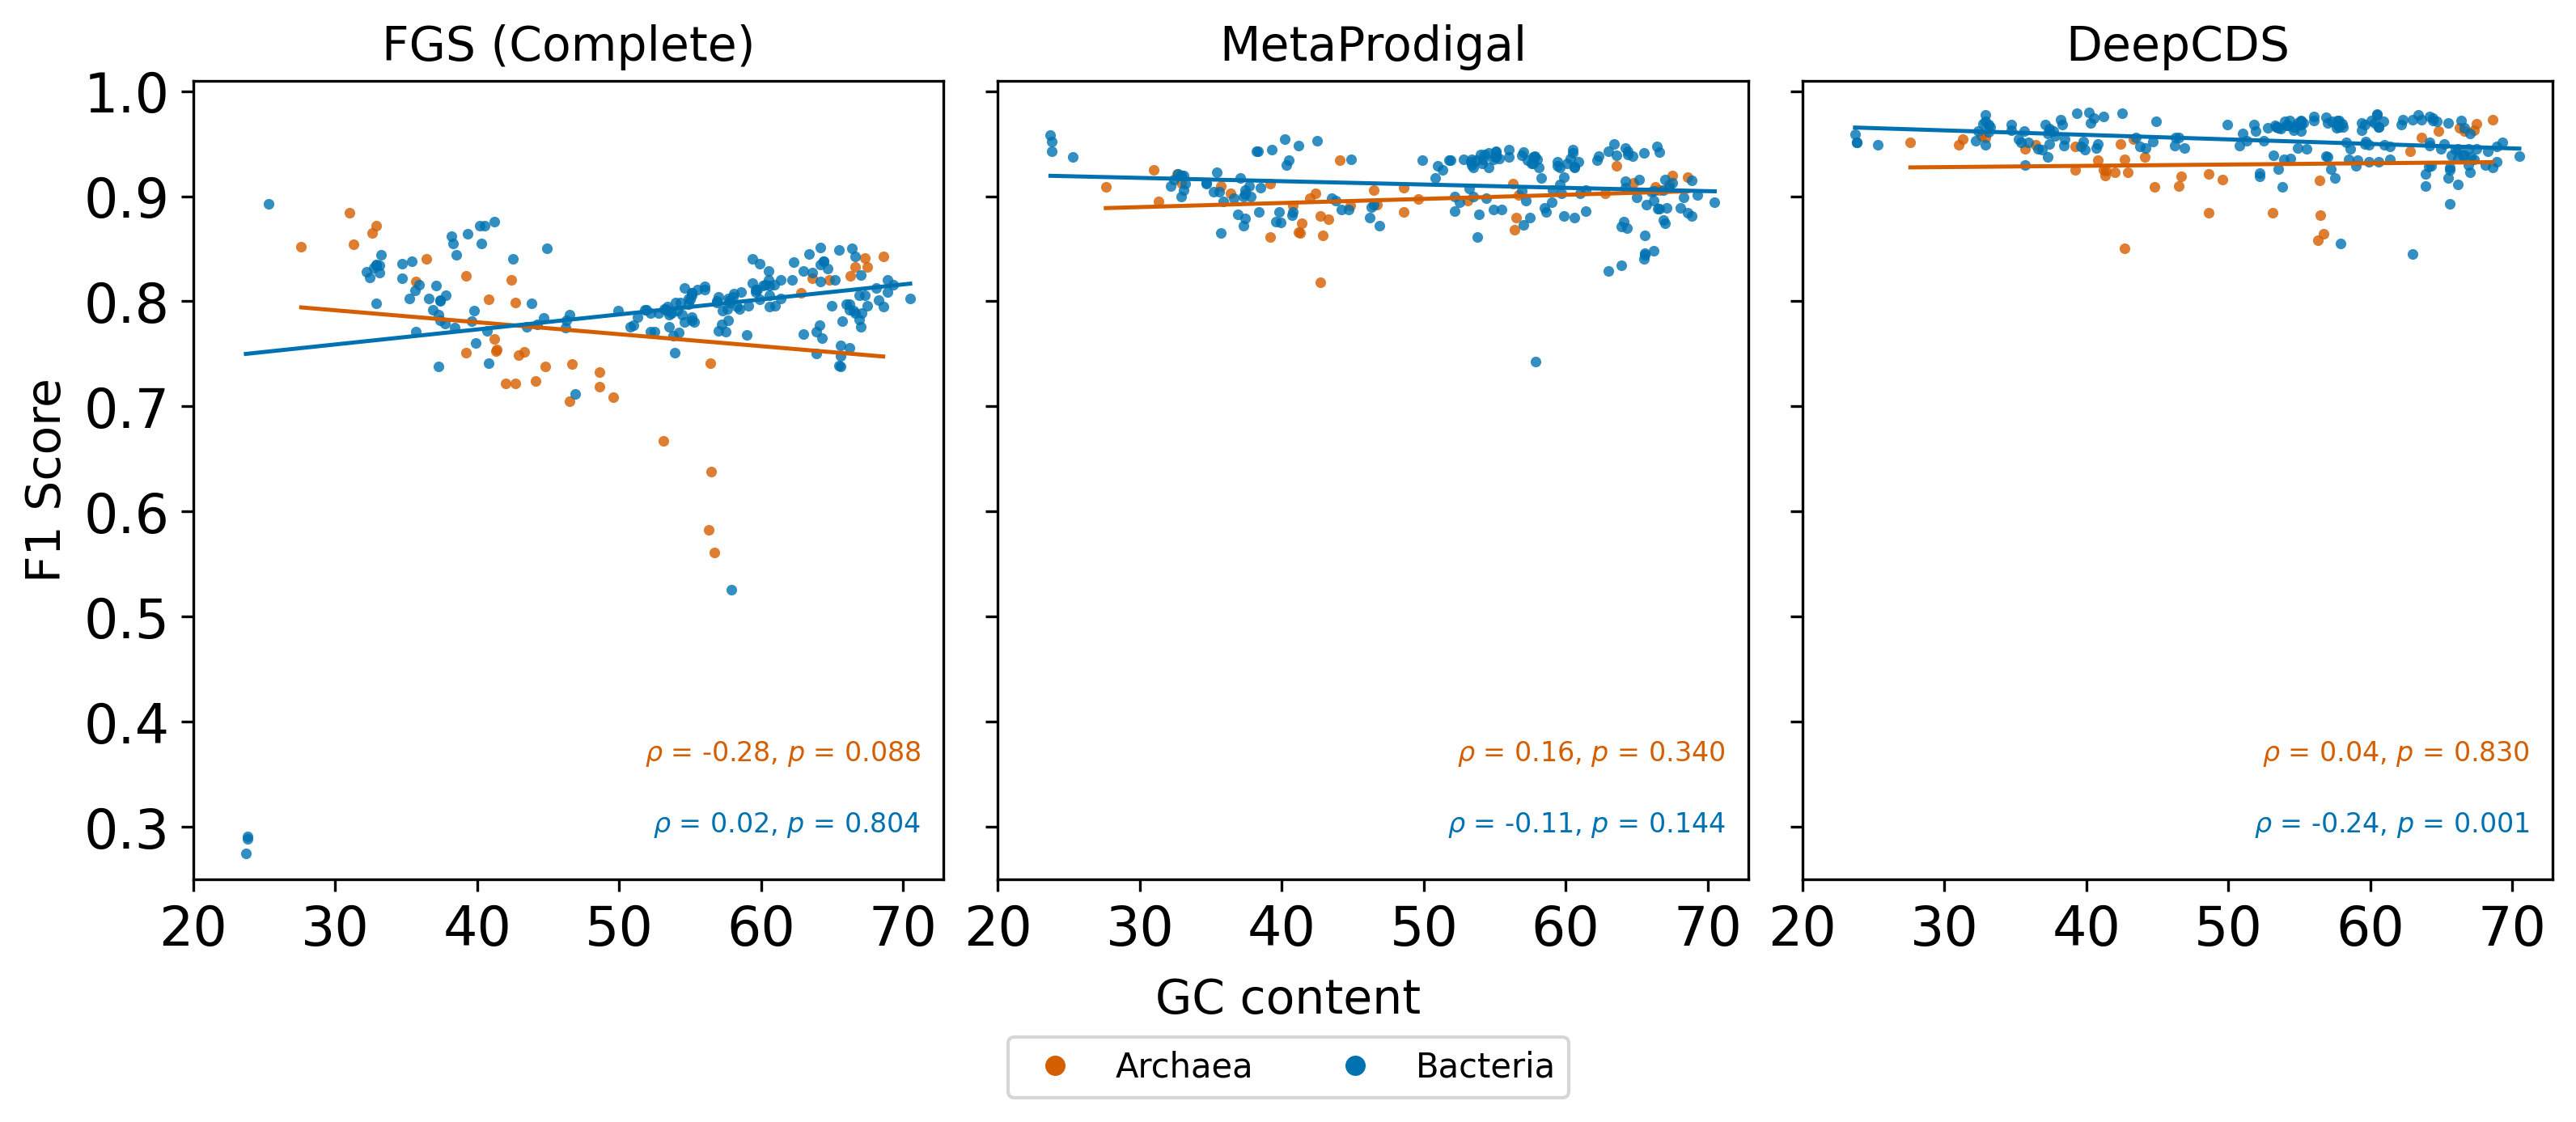

Spearman correlation: GC content vs. F1 Score
Model                      Domain          rho      p-value
------------------------------------------------------------------
FGS (Complete)             Archaea      -0.277       0.0882
FGS (Complete)             Bacteria      0.019       0.8041
MetaProdigal               Archaea       0.157       0.3401
MetaProdigal               Bacteria     -0.111       0.1443
DeepCDS                    Archaea       0.035       0.8304
DeepCDS                    Bacteria     -0.238       0.0015


In [115]:
def plot_gc_vs_metric_scatter_subset(performance_metrics_dict, genome_metadata, metric_name, data_type,
                               model_order=None, model_display_names=None, colors=None,
                               max_cols=4):
    """
    Scatterplot of GC-content vs. per-genome performance metric, one panel per model.
    Reports Spearman correlation in each panel.

    Args:
        performance_metrics_dict (dict): {accession: {model: {metric: value, ...}}}
        genome_metadata (dict): {accession: {gc_content: float, domain: str, ...}}
        metric_name (str): metric key, e.g. 'f1_score'
        data_type (str): label for the figure title / save filename
        model_order (list, optional): order of models to plot
        model_display_names (dict, optional): {model_key: display_name}
        colors (list, optional): list of bar colors per model
        max_cols (int): maximum number of panels per row (default 4)
    """
    if model_order is None:
        model_order = list(next(iter(performance_metrics_dict.values())).keys())
    if model_display_names is None:
        model_display_names = {m: m for m in model_order}
    if colors is None:
        colors = ['#D55E00', '#009E73', '#CC79A7', '#0072B2']

    # Build aligned arrays
    accessions = [acc for acc in performance_metrics_dict
                  if acc in genome_metadata and genome_metadata[acc].get('gc_content') is not None]

    gc_arr  = np.array([genome_metadata[acc]['gc_content'] for acc in accessions])
    domains = np.array([genome_metadata[acc].get('domain', 'Unknown') for acc in accessions])

    domain_colors = {'Bacteria': '#0072B2', 'Archaea': '#D55E00'}
    domain_labels = sorted(set(domains))

    n_models = len(model_order)
    n_cols = min(n_models, max_cols)
    n_rows = math.ceil(n_models / n_cols)

    matplotlib.rcParams['text.usetex'] = False
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 4.2),
                             sharey=True, constrained_layout=True)
    axes_flat = np.array(axes).flatten()

    for idx, (model, color) in enumerate(zip(model_order, colors)):
        ax = axes_flat[idx]
        f1_arr = np.array([
            performance_metrics_dict[acc][model].get(metric_name, np.nan)
            for acc in accessions
        ])
        valid = ~np.isnan(f1_arr)
        gc_v, f1_v, dom_v = gc_arr[valid], f1_arr[valid], domains[valid]

        # Points coloured by domain
        for domain in domain_labels:
            mask = dom_v == domain
            ax.scatter(gc_v[mask], f1_v[mask],
                       c=domain_colors.get(domain, 'grey'),
                       s=10, alpha=0.8, linewidths=0, label=domain)

        # Linear regression line per domain
        for domain in domain_labels:
            mask = dom_v == domain
            if mask.sum() < 2:
                continue
            gc_d, f1_d = gc_v[mask], f1_v[mask]
            m_reg, b_reg = np.polyfit(gc_d, f1_d, 1)
            x_line = np.linspace(gc_d.min(), gc_d.max(), 200)
            ax.plot(x_line, m_reg * x_line + b_reg,
                    color=domain_colors.get(domain, 'grey'), lw=1.2, zorder=5)

        # Spearman correlation per domain — bottom right corner
        annotation_lines = []
        for domain in domain_labels:
            mask = dom_v == domain
            if mask.sum() >= 3:
                rho_d, p_d = spearmanr(gc_v[mask], f1_v[mask])
                p_txt = r'$<$0.001' if p_d < 0.001 else f'= {p_d:.3f}'
                annotation_lines.append((rf'$\rho$ = {rho_d:.2f}, $p$ {p_txt}', domain_colors.get(domain, 'grey')))

        for line_idx, (text, col) in enumerate(reversed(annotation_lines)):
            ax.annotate(
                text,
                xy=(0.97, 0.05 + line_idx * 0.09), xycoords='axes fraction',
                fontsize=8, va='bottom', ha='right', color=col
            )

        ax.set_title(model_display_names.get(model, model), fontsize=14)
        ax.set_xticks(range(20, 75, 10))
        ax.set_ylim(0.25, 1.01)
        ax.set_yticks(np.arange(0.3, 1.01, 0.1))
        ax.tick_params(axis='x')

    # Hide any unused axes
    for idx in range(n_models, len(axes_flat)):
        axes_flat[idx].set_visible(False)

    # Y-axis label on leftmost column
    for row in range(n_rows):
        axes_flat[row * n_cols].set_ylabel(metric_name.replace('_', ' ').title(), fontsize=14)

    fig.supxlabel('GC content', fontsize=14)

    # Shared domain legend — centred at the bottom
    legend_handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=domain_colors.get(d, 'grey'),
               markersize=7, label=d)
        for d in domain_labels
    ]
    fig.legend(handles=legend_handles,
               loc='lower center', bbox_to_anchor=(0.5, -0.08),
               ncol=len(domain_labels)+1,
               fontsize=10, title_fontsize=10, frameon=True)

    # plt.savefig(f'gc_vs_{metric_name}_scatter_{data_type}.png', dpi=500, bbox_inches='tight')
    # plt.savefig(f'gc_vs_{metric_name}_scatter_{data_type}.svg', dpi=500, bbox_inches='tight')
    plt.show()

# Print correlation table
    print(f'Spearman correlation: GC content vs. {metric_name.replace("_", " ").title()}')
    print('=' * 66)
    print(f'{"Model":<26} {"Domain":<12} {"rho":>6} {"p-value":>12}')
    print('-' * 66)
    for model in model_order:
        f1_arr = np.array([
            performance_metrics_dict[acc][model].get(metric_name, np.nan)
            for acc in accessions
        ])
        valid = ~np.isnan(f1_arr)
        gc_v_all, f1_v_all, dom_v_all = gc_arr[valid], f1_arr[valid], domains[valid]
        for domain in domain_labels:
            mask = dom_v_all == domain
            if mask.sum() < 3:
                continue
            rho, p_rho = spearmanr(gc_v_all[mask], f1_v_all[mask])
            p_str = f'{p_rho:.3e}' if p_rho < 0.001 else f'{p_rho:.4f}'
            print(f'{model_display_names.get(model, model):<26} {domain:<12} {rho:>6.3f} {p_str:>12}')


for data_type in data_types:
    plot_gc_vs_metric_scatter_subset(
        all_performance_metrics_ordered, all_genomes, 'f1_score', data_type,
        model_order=model_order,
        model_display_names=model_display_names_ordered,
        colors=custom_colors,
    )

# Plot performance per Family

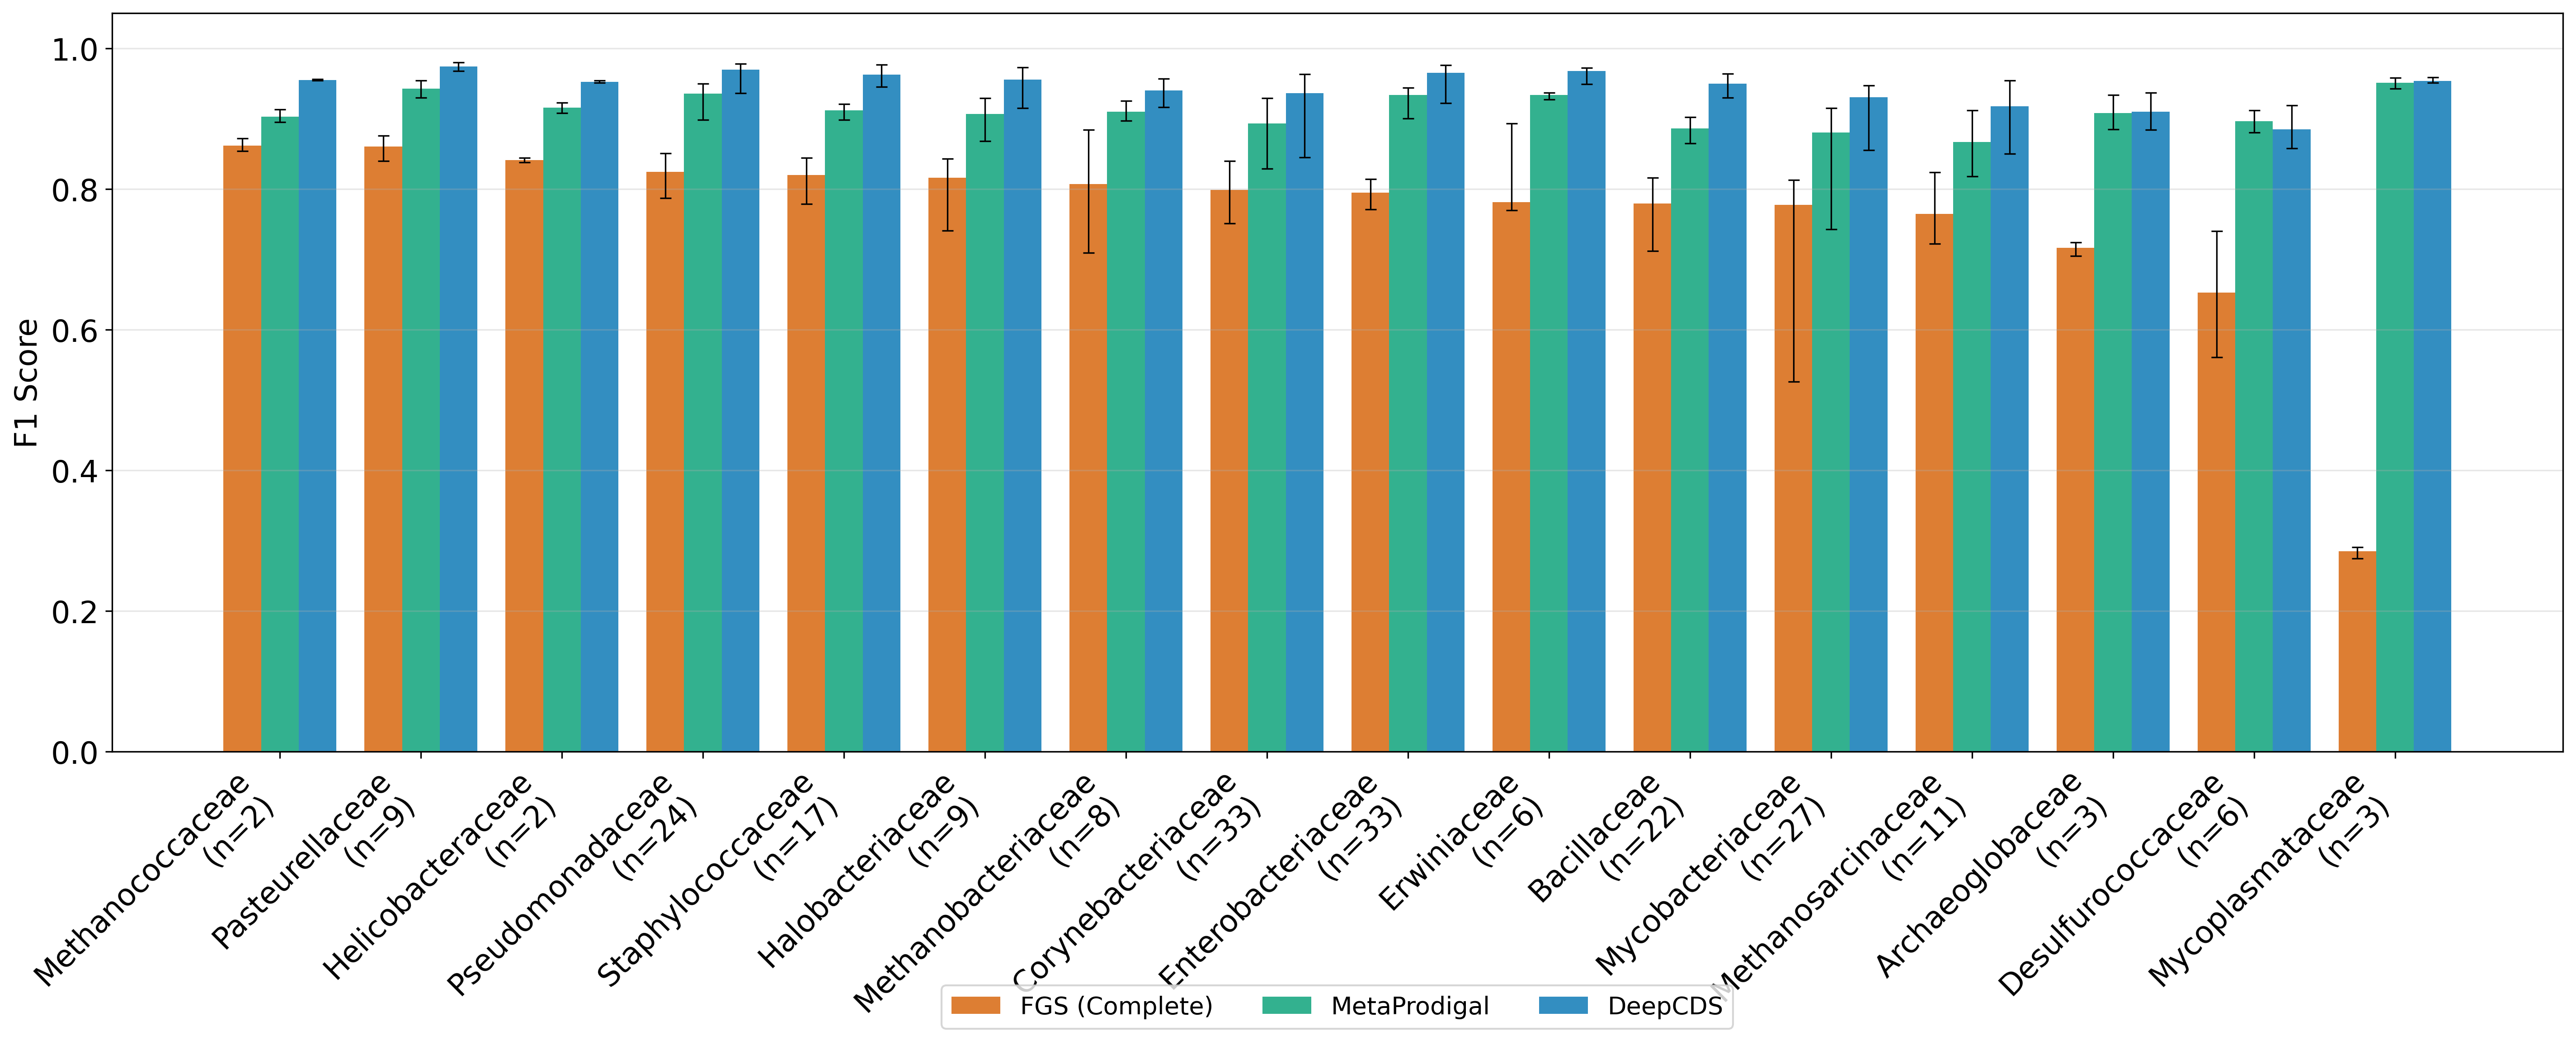

In [116]:
# Plot performance per family (aggregated across all genomes in each family)
for data_type in data_types:
    plot_metric_per_family_bars(all_performance_metrics_ordered, all_genomes, 'f1_score', data_type,
                                model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_per_family_bars(all_performance_metrics_ordered, all_genomes, 'recall', data_type,
    #                            model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    #plot_metric_per_family_bars(all_performance_metrics_ordered, all_genomes, 'precision', data_type,
    #                            model_display_names=model_display_names_ordered, colors=custom_colors_ordered)

In [117]:
# Generate LaTeX table for per-family performance (F1, Sensitivity, Precision)
def generate_family_latex_table(performance_metrics_dict, genome_metadata, model_order, model_display_names):
    """Generate a LaTeX booktabs table with family rows and model columns, best per family bolded."""
    model_names = model_order
    
    # Get all unique families and aggregate counts
    families = set()
    for acc in performance_metrics_dict.keys():
        if acc in genome_metadata:
            families.add(genome_metadata[acc]['family'])
    
    aggregated_counts = {family: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'count': 0}
                                   for model in model_names}
                         for family in families}
    
    for acc, metrics in performance_metrics_dict.items():
        if acc not in genome_metadata:
            continue
        family = genome_metadata[acc]['family']
        for model in model_names:
            if model in metrics:
                aggregated_counts[family][model]['tp'] += metrics[model].get('total_true_positives', 0)
                aggregated_counts[family][model]['fp'] += metrics[model].get('total_false_positives', 0)
                aggregated_counts[family][model]['fn'] += metrics[model].get('total_false_negatives', 0)
                aggregated_counts[family][model]['count'] += 1
    
    # Compute metrics per family per model
    family_metrics = {}
    for family in families:
        family_metrics[family] = {}
        for model in model_names:
            c = aggregated_counts[family][model]
            tp, fp, fn = c['tp'], c['fp'], c['fn']
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            family_metrics[family][model] = {'f1_score': f1, 'recall': recall, 'precision': precision}
    
    # Sort families alphabetically
    sorted_families = sorted(families)
    
    # Get genome counts per family
    genome_counts = {f: aggregated_counts[f][model_names[0]]['count'] for f in sorted_families}
    
    # Build LaTeX
    col_headers = [model_display_names.get(m, m) for m in model_names]
    n_cols = len(model_names)
    
    latex = []
    latex.append(r"\begin{table}[ht]")
    latex.append(r"\centering")
    latex.append(r"\begin{tabular}{l" + "c" * n_cols + "}")
    latex.append(r"\toprule")
    latex.append("Family (n) & " + " & ".join(col_headers) + r" \\")
    
    for metric_key, metric_label in [('f1_score', 'F1 Score')]:
        latex.append(r"\midrule")
        latex.append(r"\multicolumn{" + str(n_cols + 1) + r"}{l}{\textit{" + metric_label + r"}} \\")
        
        for family in sorted_families:
            values = [family_metrics[family][m][metric_key] for m in model_names]
            max_val = max(values)
            
            cells = []
            for v in values:
                formatted = f"{v:.3f}"
                if v == max_val:
                    cells.append(r"\textbf{" + formatted + "}")
                else:
                    cells.append(formatted)
            
            family_label = family + f" ({genome_counts[family]})"
            latex.append(family_label + " & " + " & ".join(cells) + r" \\")
    
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(r"\caption{Aggregated CDS-level performance per family}")
    latex.append(r"\label{tab:family_performance}")
    latex.append(r"\end{table}")
    
    return "\n".join(latex)

for data_type in data_types:
    table = generate_family_latex_table(all_performance_metrics_ordered, all_genomes, model_order, model_display_names_ordered)
    print(table)

\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\toprule
Family (n) & FGS (Complete) & MetaProdigal & DeepCDS \\
\midrule
\multicolumn{4}{l}{\textit{F1 Score}} \\
Archaeoglobaceae (3) & 0.716 & 0.908 & \textbf{0.910} \\
Bacillaceae (22) & 0.779 & 0.886 & \textbf{0.949} \\
Corynebacteriaceae (33) & 0.799 & 0.893 & \textbf{0.936} \\
Desulfurococcaceae (6) & 0.653 & \textbf{0.896} & 0.885 \\
Enterobacteriaceae (33) & 0.795 & 0.934 & \textbf{0.965} \\
Erwiniaceae (6) & 0.781 & 0.934 & \textbf{0.968} \\
Halobacteriaceae (9) & 0.816 & 0.907 & \textbf{0.956} \\
Helicobacteraceae (2) & 0.841 & 0.916 & \textbf{0.952} \\
Methanobacteriaceae (8) & 0.807 & 0.910 & \textbf{0.940} \\
Methanococcaceae (2) & 0.862 & 0.903 & \textbf{0.955} \\
Methanosarcinaceae (11) & 0.764 & 0.867 & \textbf{0.917} \\
Mycobacteriaceae (27) & 0.778 & 0.880 & \textbf{0.931} \\
Mycoplasmataceae (3) & 0.285 & 0.951 & \textbf{0.954} \\
Pasteurellaceae (9) & 0.861 & 0.943 & \textbf{0.974} \\
Pseudomonadaceae (24) & 0.824 

# Plot performance by GC-content separated by Translation Table

In [118]:
# Filter performance metrics by translation table
tt4_performance_metrics = {acc: metrics for acc, metrics in all_performance_metrics_dict.items() 
                           if acc in all_genomes and all_genomes[acc]['translation_table'] == 4}
tt11_performance_metrics = {acc: metrics for acc, metrics in all_performance_metrics_dict.items() 
                            if acc in all_genomes and all_genomes[acc]['translation_table'] == 11}

print(f"TT4 genomes with metrics: {len(tt4_performance_metrics)}")
print(f"TT11 genomes with metrics: {len(tt11_performance_metrics)}")

TT4 genomes with metrics: 3
TT11 genomes with metrics: 212


TRANSLATION TABLE 11 (Standard Bacterial/Archaeal Code)


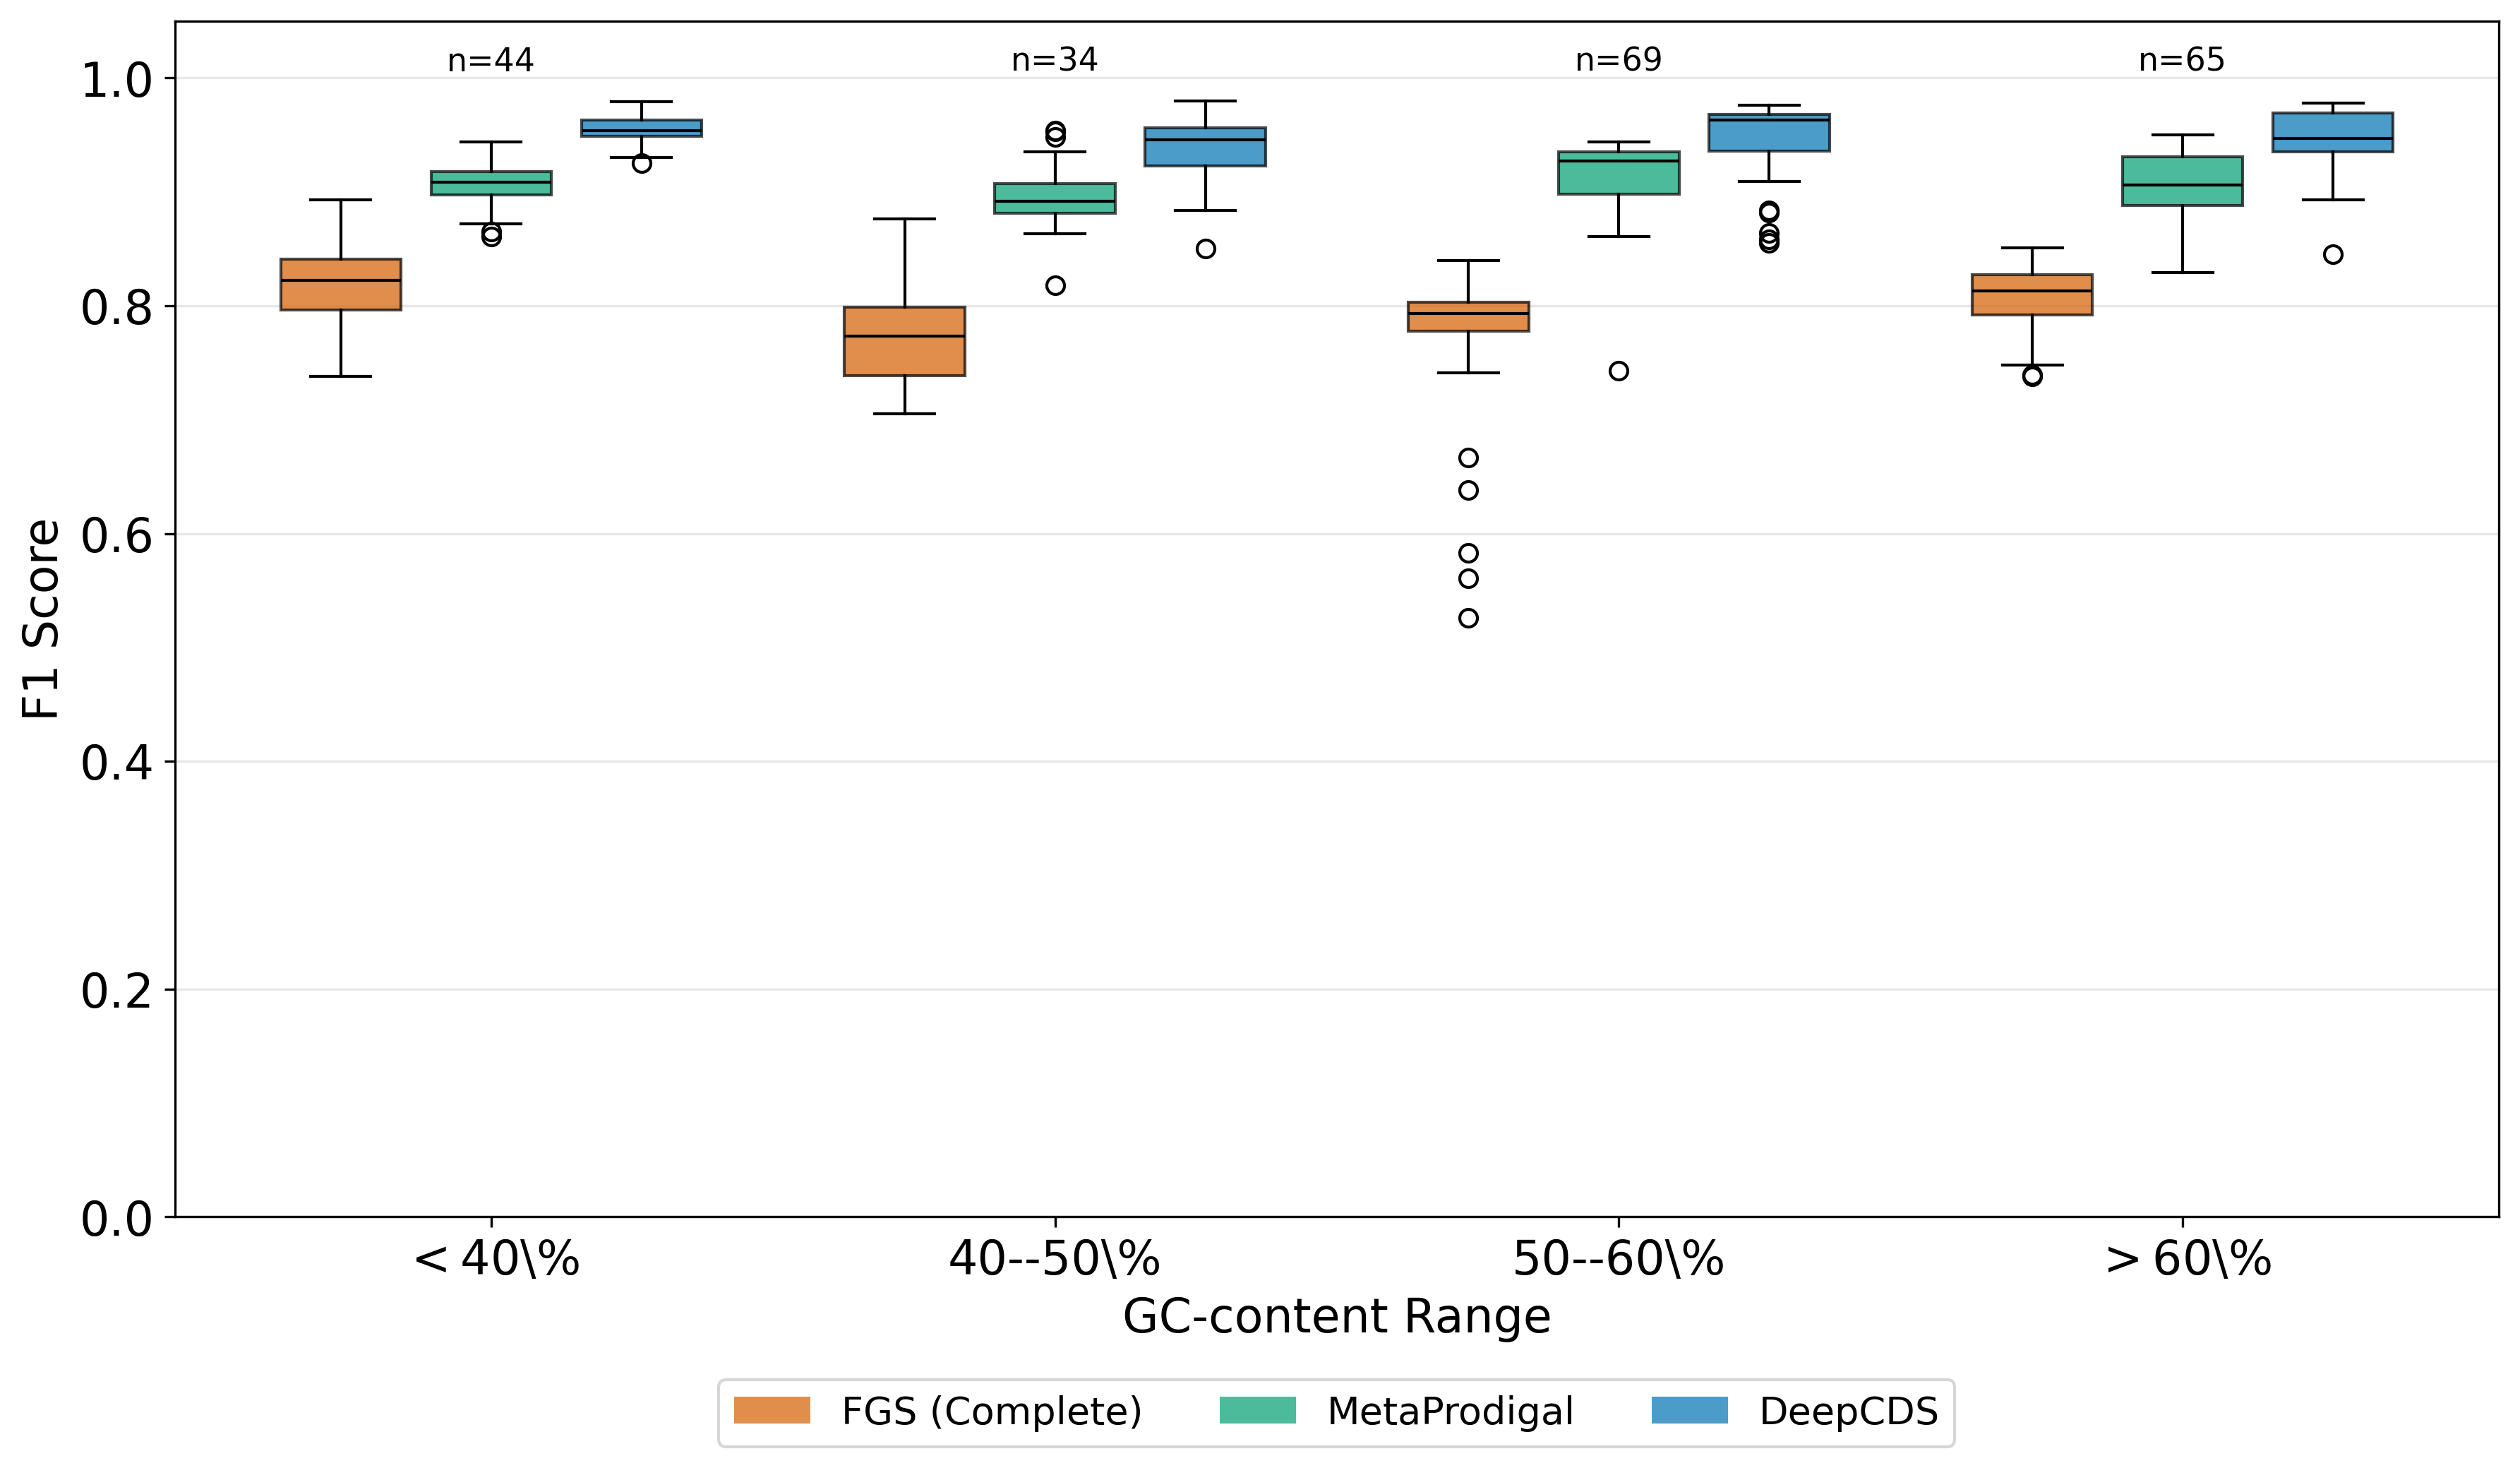

In [119]:
# Plot for Translation Table 11 only (standard bacterial/archaeal code)
tt11_performance_metrics_ordered = reorder_metrics(tt11_performance_metrics, model_order)

for data_type in data_types:
    print("=" * 60)
    print("TRANSLATION TABLE 11 (Standard Bacterial/Archaeal Code)")
    print("=" * 60)
    
    # Boxplots
    plot_metric_by_gc_content_boxplot(tt11_performance_metrics_ordered, all_genomes, 'f1_score', 
                                      f"{data_type} - Translation Table 11",
                                      model_display_names=model_display_names_ordered, colors=custom_colors_ordered)
    